In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.calibration import calibration_curve

In [2]:
import os

folder = "GSE25066_series_matrix.txt"
print("Inside the folder:")
for name in os.listdir(folder):
    print("  ", name)

Inside the folder:
   GSE25066_series_matrix.txt


In [3]:
GSE_FILE = os.path.join("GSE25066_series_matrix.txt", "GSE25066_series_matrix.txt")

In [4]:
import os
GSE_FILE= os.path.join("GSE25066_series_matrix.txt", "GSE25066_series_matrix.txt")
with open(GSE_FILE, encoding="latin-1") as f:
    lines=f.readlines()
print(f"Total lines in file: {len(lines)}")
sample_lines= [ln for ln in lines if ln.startswith("!Sample_")]
print(f"Sample metadata lines: {len(sample_lines)}\n")
for ln in sample_lines:
    parts=ln.split("\t")
    label= parts[0]
    example=parts[1].strip().strip('"') if len(parts)> 1 else ""
    print(f"{label:35s} e.g. -> {example}")
                                   


Total lines in file: 22374
Sample metadata lines: 56

!Sample_title                       e.g. -> 1002
!Sample_geo_accession               e.g. -> GSM615096
!Sample_status                      e.g. -> Public on May 11 2011
!Sample_submission_date             e.g. -> Nov 01 2010
!Sample_last_update_date            e.g. -> Jun 06 2022
!Sample_type                        e.g. -> RNA
!Sample_channel_count               e.g. -> 1
!Sample_source_name_ch1             e.g. -> breast cancer, sample ISPY-1002
!Sample_organism_ch1                e.g. -> Homo sapiens
!Sample_characteristics_ch1         e.g. -> sample id: 1002
!Sample_characteristics_ch1         e.g. -> source: ISPY
!Sample_characteristics_ch1         e.g. -> age_years: 37.8
!Sample_characteristics_ch1         e.g. -> er_status_ihc: P
!Sample_characteristics_ch1         e.g. -> pr_status_ihc: P
!Sample_characteristics_ch1         e.g. -> her2_status: N
!Sample_characteristics_ch1         e.g. -> er_status_ihc_esr1_for indeterminate

In [5]:
import pandas as pd
char_lines=[ln for ln in lines if ln.startswith("!Sample_characteristics_ch1")]
id_line=[ln for ln in lines if ln.startswith("!Sample_geo_accession")][0]
sample_ids= [x.strip().strip('"') for x in id_line.split("\t")[1:]]
clin_geo=pd.DataFrame(index=sample_ids)
for ln in char_lines:
    cells=[c.strip().strip('"') for c in ln.split("\t")[1:]]   #split on tabs, drop label
    field_name= cells[0].split(":")[0].strip()
    values=[c.split(":",1)[1].strip() if ":" in c else None for c in cells]
    clin_geo[field_name]=pd.Series(values,index=sample_ids[:len(values)])   #INSIDE the loop

print("Shape:", clin_geo.shape)
clin_geo.head()

Shape: (508, 24)


,sample id,source,age_years,er_status_ihc,pr_status_ihc,her2_status,er_status_ihc_esr1_for indeterminate,clinical_t_stage,clinical_nodal_status,clinical_ajcc_stage,...,drfs_even_time_years,esr1_status,erbb2_status,set_class,chemosensitivity_prediction,ggi_class,pam50_class,dlda30_prediction,rcb_0_i_prediction,tissue
GSM615096,1002,ISPY,37.8,P,P,N,P,T2,N1,IIB,...,2.346,P,N,SET-High,Rx Sensitive,Low,LumA,RD,RCB-0/I,breast cancer tumor
GSM615097,1005,ISPY,45.8,P,P,N,P,T3,N1,IIIA,...,5.552,P,N,SET-Int,Rx Sensitive,Low,Normal,RD,RCB-0/I,breast cancer tumor
GSM615098,1009,ISPY,40.7,N,N,N,N,T3,N0,IIB,...,5.503,N,N,SET-Low,Rx Insensitive,High,Basal,pCR,RCB-II/III,breast cancer tumor
GSM615099,1011,ISPY,40.8,N,N,N,N,T2,N1,IIB,...,5.424,N,N,SET-Low,Rx Insensitive,High,Basal,pCR,RCB-0/I,breast cancer tumor
GSM615100,1016,ISPY,35.5,P,P,N,P,T3,N1,IIIA,...,1.580,P,N,SET-Low,Rx Insensitive,High,LumA,RD,RCB-II/III,breast cancer tumor


In [6]:
import pandas as pd
char_lines=[ln for ln in lines if ln.startswith("!Sample_characteristics_ch1")]
id_line=[ln for ln in lines if ln.startswith("!Sample_geo_accession")][0]
sample_ids= [x.strip().strip('"') for x in id_line.split("\t")[1:]]
n_patients=len(sample_ids)
print("Number of patients:", n_patients)
clin_geo=pd.DataFrame(index=sample_ids)
for ln in char_lines:
    cells=[c.strip().strip('"') for c in ln.strip("\t")[1:]]
    if len(cells) !=n_patients:
        print(f"(skipped a line with {len(cells)} values, expected {n_patients})")
        continue
    field_name= cells[0].split(":")[0].strip()
    values=[c.split(":",1)[1].strip() if ":" in c else None for c in cells]
    clin_geo[field_name]=pd.Series(values,index=sample_ids[:len(values)])
print("\nShape:", clin_geo.shape)
clin_geo.head()

Number of patients: 508
(skipped a line with 9195 values, expected 508)
(skipped a line with 8254 values, expected 508)
(skipped a line with 9171 values, expected 508)
(skipped a line with 9681 values, expected 508)
(skipped a line with 9681 values, expected 508)
(skipped a line with 8676 values, expected 508)
(skipped a line with 17601 values, expected 508)
(skipped a line with 12701 values, expected 508)
(skipped a line with 14138 values, expected 508)
(skipped a line with 10748 values, expected 508)
(skipped a line with 10231 values, expected 508)
(skipped a line with 17969 values, expected 508)
(skipped a line with 18298 values, expected 508)
(skipped a line with 17130 values, expected 508)
(skipped a line with 13761 values, expected 508)
(skipped a line with 8663 values, expected 508)
(skipped a line with 9171 values, expected 508)
(skipped a line with 10719 values, expected 508)
(skipped a line with 23057 values, expected 508)
(skipped a line with 8999 values, expected 508)
(skip

""
GSM615096
GSM615097
GSM615098
GSM615099
GSM615100


In [7]:
# Show the raw structure of the first characteristic line
char_lines = [ln for ln in lines if ln.startswith("!Sample_characteristics_ch1")]
first = char_lines[0]

print("Number of tab-splits:", len(first.split("\t")))
print("Number of patients expected:", len([ln for ln in lines if ln.startswith('!Sample_geo_accession')][0].split("\t")) - 1)
print("\nFirst 400 characters of the raw line:\n")
print(repr(first[:400]))

Number of tab-splits: 509
Number of patients expected: 508

First 400 characters of the raw line:

'!Sample_characteristics_ch1\t"sample id: 1002"\t"sample id: 1005"\t"sample id: 1009"\t"sample id: 1011"\t"sample id: 1016"\t"sample id: 1019"\t"sample id: 1027"\t"sample id: 1031"\t"sample id: 1034"\t"sample id: 1035"\t"sample id: 1037"\t"sample id: 1038"\t"sample id: 1041"\t"sample id: 1044"\t"sample id: 1045"\t"sample id: 1049"\t"sample id: 1050"\t"sample id: 1054"\t"sample id: 1055"\t"sample id: 1057"\t"sample id: '


In [8]:
import pandas as pd
import re
char_lines= [ln for ln in lines if ln.startswith("!Sample_characteristics_ch1")]
id_line= [ln for ln in lines if ln.startswith("!Sample_geo_accession")][0]
sample_ids=[x.strip().strip('"') for x in id_line.split("\t")[1:]]
n_patients=len(sample_ids)
clin_geo=pd.DataFrame(index=sample_ids)
for ln in char_lines:
    quoted=re.findall(r'"([^"]*)"', ln)
    if len(quoted) != n_patients:
        continue
    field_name=quoted[0].split(":")[0].strip()
    values= [v.split(":",1)[1].strip()if ":" in v else None for v in quoted]
    clin_geo[field_name]=values
print("Shape:", clin_geo.shape)
print("Columns:", list(clin_geo.columns))
clin_geo.head()



Shape: (508, 24)
Columns: ['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue']


,sample id,source,age_years,er_status_ihc,pr_status_ihc,her2_status,er_status_ihc_esr1_for indeterminate,clinical_t_stage,clinical_nodal_status,clinical_ajcc_stage,...,drfs_even_time_years,esr1_status,erbb2_status,set_class,chemosensitivity_prediction,ggi_class,pam50_class,dlda30_prediction,rcb_0_i_prediction,tissue
GSM615096,1002,ISPY,37.8,P,P,N,P,T2,N1,IIB,...,2.346,P,N,SET-High,Rx Sensitive,Low,LumA,RD,RCB-0/I,breast cancer tumor
GSM615097,1005,ISPY,45.8,P,P,N,P,T3,N1,IIIA,...,5.552,P,N,SET-Int,Rx Sensitive,Low,Normal,RD,RCB-0/I,breast cancer tumor
GSM615098,1009,ISPY,40.7,N,N,N,N,T3,N0,IIB,...,5.503,N,N,SET-Low,Rx Insensitive,High,Basal,pCR,RCB-II/III,breast cancer tumor
GSM615099,1011,ISPY,40.8,N,N,N,N,T2,N1,IIB,...,5.424,N,N,SET-Low,Rx Insensitive,High,Basal,pCR,RCB-0/I,breast cancer tumor
GSM615100,1016,ISPY,35.5,P,P,N,P,T3,N1,IIIA,...,1.580,P,N,SET-Low,Rx Insensitive,High,LumA,RD,RCB-II/III,breast cancer tumor


In [9]:
print("All columns:")
print(list(clin_geo.columns))
print("\npCR outcome value counts:")
print(clin_geo["pathologic_response_pcr_rd"].value_counts(dropna=False))


All columns:
['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue']

pCR outcome value counts:
pathologic_response_pcr_rd
RD         249
NA          86
pCR         57
RCB-II      53
RCB-0/I     32
RCB-III     31
Name: count, dtype: int64


In [10]:
pcr_map={"pCR":1, "RD":0, "RBC-II":0,}
clin_geo["pcr"]=clin_geo["pathologic_response_pcr_rd"].map(pcr_map)
before=len(clin_geo)
geo=clin_geo.dropna(subset=["pcr"]).copy()
after=len(geo)
print(f"Kept {after} of {before} patients (dropped {before-after} with NA/ambiguous outcome)")
print("\npCR rate:",f"{geo['pcr'].mean():.1%}")
print(geo["pcr"].value_counts())

Kept 306 of 508 patients (dropped 202 with NA/ambiguous outcome)

pCR rate: 18.6%
pcr
0.0    249
1.0     57
Name: count, dtype: int64


In [11]:
candidates= ["age_years", "er_status_ihc", "pr_status_ihc", "her2_status", "grade", "clinical_t_stage", "clinical_nodal_status", "clinical_ajcc_stage"]
for col in candidates:
    print(f"--- {col} ---")
    print(geo[col].value_counts(dropna=False))
    print()

--- age_years ---
age_years
46.0    12
51.0    12
50.0    11
47.0    10
49.0    10
        ..
29.0     1
26.0     1
30.0     1
33.0     1
28.0     1
Name: count, Length: 111, dtype: int64

--- er_status_ihc ---
er_status_ihc
P     172
N     129
I       4
NA      1
Name: count, dtype: int64

--- pr_status_ihc ---
pr_status_ihc
N     160
P     140
I       5
NA      1
Name: count, dtype: int64

--- her2_status ---
her2_status
N     288
NA     11
I       4
P       3
Name: count, dtype: int64

--- grade ---
grade
3                  149
2                  116
1                   19
4=Indeterminate     15
NA                   7
Name: count, dtype: int64

--- clinical_t_stage ---
clinical_t_stage
T2    163
T3     73
T4     48
T1     20
T0      2
Name: count, dtype: int64

--- clinical_nodal_status ---
clinical_nodal_status
N1    150
N0     87
N2     39
N3     30
Name: count, dtype: int64

--- clinical_ajcc_stage ---
clinical_ajcc_stage
IIB             90
IIA             73
IIIA            67
I

In [12]:
categorical_candidates= ["er_status_ihc","pr_status_ihc", "her2_status","grade","clinical_t_stage","clinical_nodal_status","clinical_ajcc_stage"]
for col in categorical_candidates:
    vals=geo[col].value_counts(dropna=False)
    summary=",".join(f"{k}={v}" for k, v in vals.items())
    print(f"{col}:{summary}")

er_status_ihc:P=172,N=129,I=4,NA=1
pr_status_ihc:N=160,P=140,I=5,NA=1
her2_status:N=288,NA=11,I=4,P=3
grade:3=149,2=116,1=19,4=Indeterminate=15,NA=7
clinical_t_stage:T2=163,T3=73,T4=48,T1=20,T0=2
clinical_nodal_status:N1=150,N0=87,N2=39,N3=30
clinical_ajcc_stage:IIB=90,IIA=73,IIIA=67,IIIB=53,IIIC=13,I=6,Inflammatory=4


In [13]:
import numpy as np
model_df=geo.copy()
model_df["age_years"]=pd.to_numeric(model_df["age_years"], errors="coerce")
missing_markers=["NA","I", "Indeterminate","Inflammatory",""]
cat_features=["er_status_ihc","pr_status_ihc","grade","clinical_t_stage","clinical_nodal_status"]
for col in cat_features:
    model_df[col]=model_df[col].replace(missing_markers, np.nan)
features=["age_years"]+cat_features
print("Missing values per feature:")
print(model_df[features].isna().sum())
print("\npCR rate:", f"{model_df['pcr'].mean():.1%}","| patients:", len (model_df))

Missing values per feature:
age_years                0
er_status_ihc            5
pr_status_ihc            6
grade                    7
clinical_t_stage         0
clinical_nodal_status    0
dtype: int64

pCR rate: 18.6% | patients: 306


In [14]:
from scipy import stats
y_geo=model_df["pcr"]
print("=== NUMERIC: age vs pCR (t-test) ===")
g1=model_df.loc[y_geo==1,"age_years"].dropna()
g0=model_df.loc[y_geo==0, "age_years"].dropna()
_, p=stats.ttest_ind(g1,g0,equal_var=False)
print(f"age_years pCR{g1.mean():.1f}±{g1.std():.1f}| non-pCR {g0.mean():.1f}±{g0.std():.1f} | p = {p:.3f}\n")
print("===CATEGORICAL:each feature vs pCR (chi-square)===")
for col in cat_features:
    sub=model_df[[col, "pcr"]].dropna()
    table=pd.crosstab(sub[col],sub["pcr"])
    chi2, p, dof,_= stats.chi2_contingency(table)
    print(f"{col:22s} p={p:.4f}")

=== NUMERIC: age vs pCR (t-test) ===
age_years pCR48.0±9.9| non-pCR 50.7±10.5 | p = 0.072

===CATEGORICAL:each feature vs pCR (chi-square)===
er_status_ihc          p=0.0000
pr_status_ihc          p=0.0000
grade                  p=0.0000
clinical_t_stage       p=0.3056
clinical_nodal_status  p=0.5973


C:\Users\HP\AppData\Local\Temp\ipykernel_21308\1866755384.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([age_non, age_pcr], labels=["non-pCR", "pCR"])


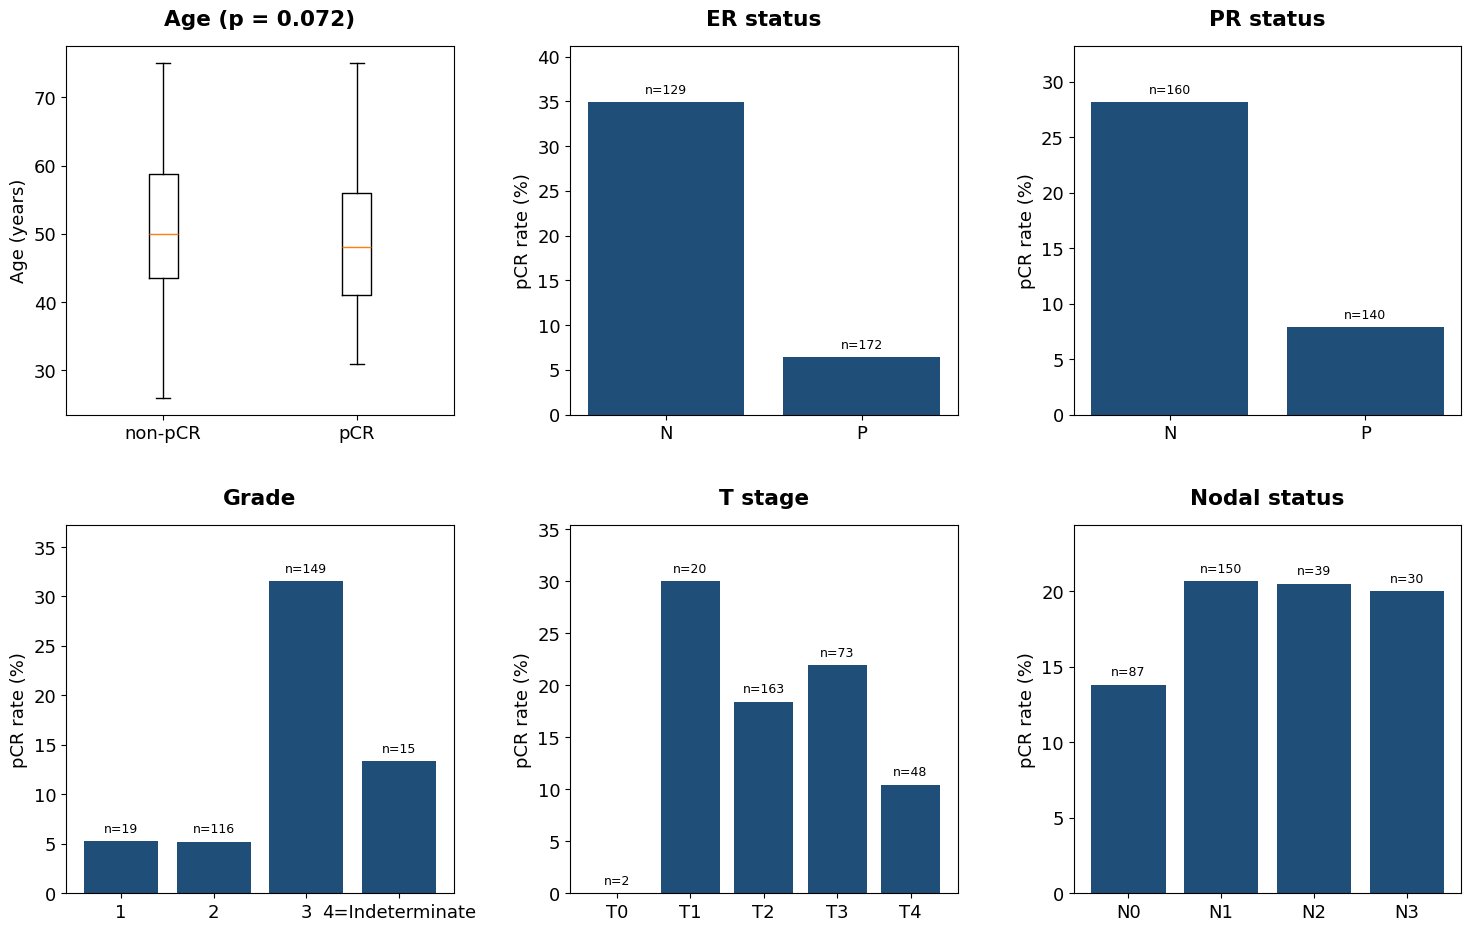

In [15]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 13})

cat_to_plot = ["er_status_ihc", "pr_status_ihc", "grade",
               "clinical_t_stage", "clinical_nodal_status"]
nice_names = {
    "er_status_ihc": "ER status", "pr_status_ihc": "PR status", "grade": "Grade",
    "clinical_t_stage": "T stage", "clinical_nodal_status": "Nodal status",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

ax = axes[0]
age_pcr = model_df.loc[model_df["pcr"] == 1, "age_years"].dropna()
age_non = model_df.loc[model_df["pcr"] == 0, "age_years"].dropna()
ax.boxplot([age_non, age_pcr], labels=["non-pCR", "pCR"])
ax.set_title("Age (p = 0.072)", fontweight="bold", pad=15)
ax.set_ylabel("Age (years)")

for i, col in enumerate(cat_to_plot, start=1):
    ax = axes[i]
    rate = model_df.groupby(col)["pcr"].mean() * 100
    counts = model_df.groupby(col)["pcr"].size()
    bars = ax.bar(rate.index.astype(str), rate.values, color="#1F4E78")
    ax.set_title(nice_names[col], fontweight="bold", pad=15)
    ax.set_ylabel("pCR rate (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, rate.max() * 1.18)
    # small horizontal n= label just below the top of each bar (or above short bars)
    for bar, cat in zip(bars, rate.index):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + rate.max() * 0.02,          # just ABOVE each bar
                f"n={counts[cat]}",
                ha="center", va="bottom", fontsize=9, color="black")

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.savefig("feature_associations.png", dpi=300, bbox_inches="tight")
plt.show()

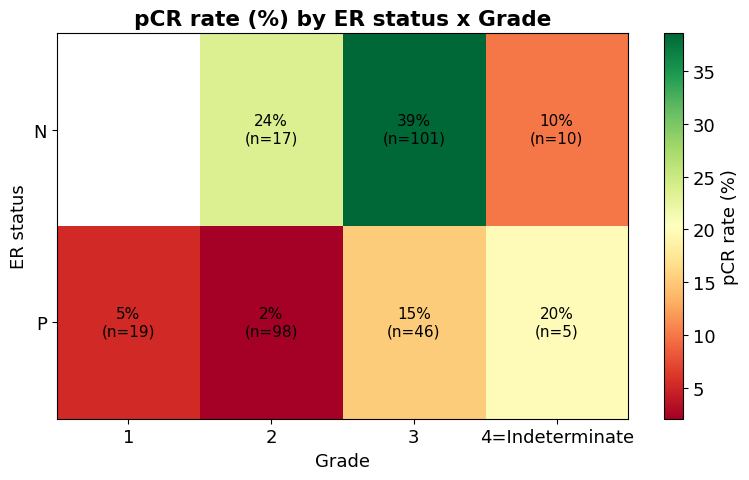

In [16]:
import matplotlib.pyplot as plt
import numpy as np
sub=model_df[["er_status_ihc","grade","pcr"]].dropna()
rate_grid=sub.pivot_table(index="er_status_ihc", columns="grade", values="pcr", aggfunc="mean")*100
count_grid=sub.pivot_table(index="er_status_ihc", columns="grade", values="pcr", aggfunc="size")
fig,ax=plt.subplots(figsize=(8,5))
im=ax.imshow(rate_grid.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(rate_grid.columns)))
ax.set_xticklabels(rate_grid.columns)
ax.set_yticks(range(len(rate_grid.index)))
ax.set_yticklabels(rate_grid.index)
ax.set_xlabel("Grade")
ax.set_ylabel("ER status")
ax.set_title("pCR rate (%) by ER status x Grade", fontweight="bold")
cbar=fig.colorbar(im,ax=ax)
cbar.set_label("pCR rate (%)")
for r in range(rate_grid.shape[0]):
    for c in range (rate_grid.shape[1]):
        rate=rate_grid.values[r,c]
        n=count_grid.values[r,c]
        if not np.isnan(rate):
            ax.text(c,r,f"{rate:.0f}%\n(n={int(n)})", ha="center", va="center", fontsize=11, color="black") 
plt.tight_layout()
plt.savefig("interaction_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
             

In [17]:
model_df["grade"]=model_df["grade"].replace("4=Indeterminate",np.nan)
print(model_df["grade"].value_counts(dropna=False))

grade
3      149
2      116
NaN     22
1       19
Name: count, dtype: int64


In [18]:
NUMERIC_GEO=["age_years"]
CATEGORICAL_GEO=["er_status_ihc","pr_status_ihc","grade","clinical_t_stage","clinical_nodal_status"]

X_geo=model_df[NUMERIC_GEO+CATEGORICAL_GEO].copy()
Y_geo=model_df["pcr"].astype(int)

print("Feature matrix shape:", X_geo.shape)
print("pCR rate:",f"{Y_geo.mean():.1%}","| p    tients:", len(Y_geo))
print("\nMissing values per feature:")
print(X_geo.isna().sum())

Feature matrix shape: (306, 6)
pCR rate: 18.6% | p    tients: 306

Missing values per feature:
age_years                 0
er_status_ihc             5
pr_status_ihc             6
grade                    22
clinical_t_stage          0
clinical_nodal_status     0
dtype: int64


In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score


In [20]:
preprocess_geo=ColumnTransformer([
    ("num",Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ]),NUMERIC_GEO),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
            ]),CATEGORICAL_GEO),
])
model_geo=LogisticRegression(max_iter=1000,class_weight="balanced")
pipe_geo=Pipeline([("prep",preprocess_geo),("model",model_geo)])
cv_geo=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
probs_geo=cross_val_predict(pipe_geo, X_geo, Y_geo, cv=cv_geo, method="predict_proba")[:,1]
auc_geo=roc_auc_score(Y_geo, probs_geo)
print(f"Rich clinical model - AUC={auc_geo:.3f}")

Rich clinical model - AUC=0.755


In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
rng=np.random.default_rng(42)
boot=[]
for _ in range(2000):
    i=rng.integers(0,len(Y_geo),len(Y_geo))
    if len(np.unique(Y_geo.iloc[i]))==2:
        boot.append(roc_auc_score(Y_geo.iloc[i], probs_geo[i]))
lo, hi = np.percentile(boot, [2.5, 97.5])
pred=(probs_geo >= 0.5).astype(int)
tn,fp,fn,tp=confusion_matrix(Y_geo, pred).ravel()
sens=tp/(tp+fn)
spec=tn/(tn+fp)
print(f"AUC {auc_geo:.3f} (95% CI {lo:.3f}-{hi:.3f})")
print(f"Sensitivity {sens:.2f} | Specificity {spec:.2f}")


AUC 0.755 (95% CI 0.687-0.816)
Sensitivity 0.74 | Specificity 0.67


<function matplotlib.pyplot.show(close=None, block=None)>

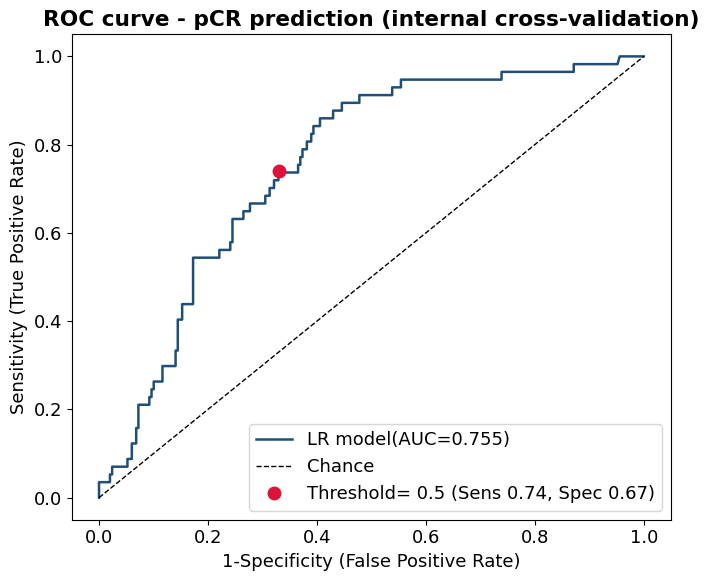

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc
fpr, tpr, thresholds= roc_curve(Y_geo, probs_geo)
roc_auc=auc(fpr,tpr)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="#1F4E78", lw=1.8,
         label=f"LR model(AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], "k--", lw=1, label="Chance")
op_fpr, op_tpr= 1 - 0.67, 0.74    #x=1 - specificity, y=sensitivity
plt.plot(op_fpr, op_tpr, "o", color="crimson", markersize=9,
         label="Threshold= 0.5 (Sens 0.74, Spec 0.67)")

plt.xlabel("1-Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC curve - pCR prediction (internal cross-validation)", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_geo_model.png", dpi=300, bbox_inches="tight")
plt.show       

Optimal threshold(Youden): 0.367
Sensitivity: 0.86
Specificity: 0.59


<function matplotlib.pyplot.show(close=None, block=None)>

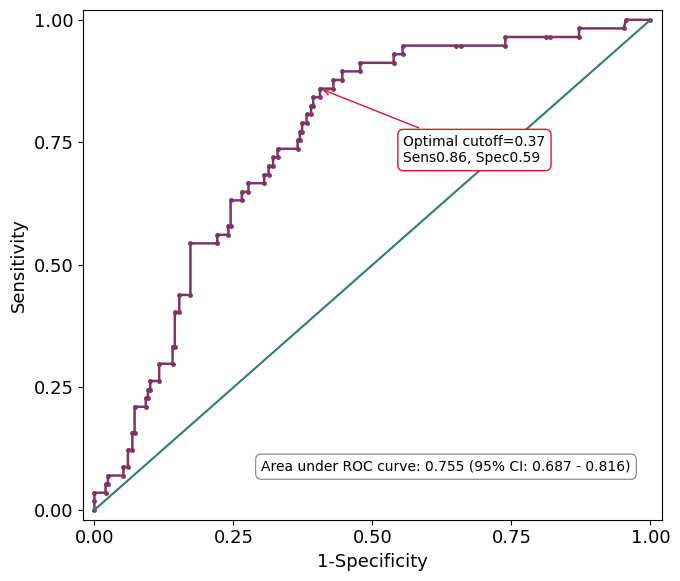

In [23]:
fpr, tpr, thresholds=roc_curve(Y_geo, probs_geo)
roc_auc=auc(fpr,tpr)

#Youden index: find the threshold that maximises (sensitivity + specificity - 1)
youden=tpr-fpr
best_idx=np.argmax(youden)
best_threshold=thresholds[best_idx]
best_sens=tpr[best_idx]
best_spec=1-fpr[best_idx]

print(f"Optimal threshold(Youden): {best_threshold:.3f}")
print(f"Sensitivity: {best_sens:.2f}")
print(f"Specificity: {best_spec:.2f}")

#Plot the ROC with the optimal point marked
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr, color="#7F3564", lw=1.8, marker="o", markersize=2.5)
plt.plot([0, 1], [0, 1], color="#2E7D6F", lw=1.5)
plt.annotate(f"Optimal cutoff={best_threshold:.2f}\nSens{best_sens:.2f}, Spec{best_spec:.2f}",
             xy=(fpr[best_idx], tpr[best_idx]),
             xytext=(fpr[best_idx] + 0.15, tpr[best_idx] - 0.15),
             arrowprops=dict (arrowstyle="->", color="crimson"),fontsize=10,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="crimson", linewidth=1),)

plt.text(0.30,0.08,
          f"Area under ROC curve: {roc_auc:.3f} (95% CI: 0.687 - 0.816)", 
          fontsize=10,
          bbox=dict(boxstyle="round, pad=0.4", facecolor="white", edgecolor="grey", linewidth=0.8))
plt.xticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.xlabel("1-Specificity")
plt.ylabel("Sensitivity")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig("roc_geo_optimal.png", dpi=300, bbox_inches="tight")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

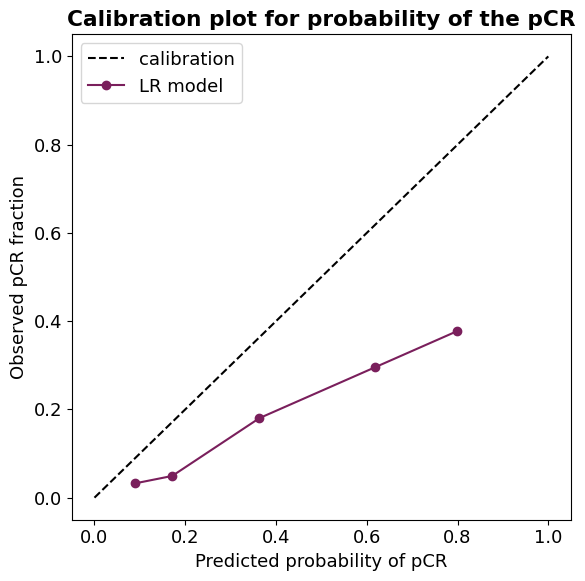

In [24]:
observed, predicted= calibration_curve(Y_geo, probs_geo,n_bins=5, strategy="quantile")
plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], "k--", label= "calibration")
plt.plot(predicted, observed, "o-", color="#7A1F5C", label="LR model")
plt.xlabel("Predicted probability of pCR")
plt.ylabel("Observed pCR fraction")
plt.title("Calibration plot for probability of the pCR", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("calibration_geo.png", dpi=300, bbox_inches="tight")
plt.show


AUC before 0.755
AUC after  0.749


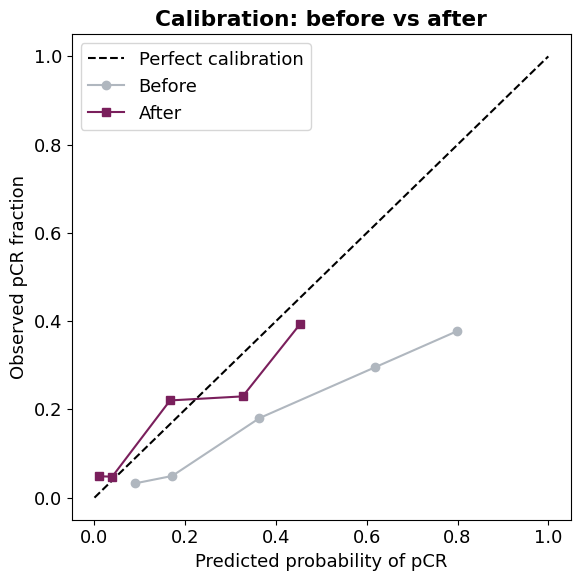

In [25]:
# Isotonic calibration - REJECTED alternative.
# Platt scaling (method='sigmoid') was adopted: Brier 0.134 vs 0.140 isotonic.
# Retained so the comparison reported in the paper is reproducible.
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
calibrated_geo = CalibratedClassifierCV(pipe_geo, method="isotonic", cv=5)
cal_probs_geo = cross_val_predict(calibrated_geo, X_geo, y_geo, cv=cv_geo, method="predict_proba")[:, 1]

print(f"AUC before {roc_auc_score(y_geo, probs_geo):.3f}")
print(f"AUC after  {roc_auc_score(y_geo, cal_probs_geo):.3f}")

obs_old, pred_old = calibration_curve(y_geo, probs_geo, n_bins=5, strategy="quantile")
obs_new, pred_new = calibration_curve(y_geo, cal_probs_geo, n_bins=5, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(pred_old, obs_old, "o-", color="#B0B7BF", label="Before")
plt.plot(pred_new, obs_new, "s-", color="#7A1F5C", label="After")
plt.xlabel("Predicted probability of pCR")
plt.ylabel("Observed pCR fraction")
plt.title("Calibration: before vs after", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("calibration_geo_beforeafter.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
feature_sets = {
    "6 features (all)":       ["age_years", "er_status_ihc", "pr_status_ihc",
                               "grade", "clinical_t_stage", "clinical_nodal_status"],
    "4 features (confident)": ["age_years", "er_status_ihc", "pr_status_ihc", "grade"],
}

for name, feats in feature_sets.items():
    num = [f for f in feats if f == "age_years"]
    cat = [f for f in feats if f != "age_years"]
    prep = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), num),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])
    pipe = Pipeline([("prep", prep),
                     ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
    p = cross_val_predict(pipe, model_df[feats], y_geo, cv=cv_geo, method="predict_proba")[:, 1]
    print(f"{name:26s} AUC = {roc_auc_score(y_geo, p):.3f}")

6 features (all)           AUC = 0.755
4 features (confident)     AUC = 0.753


In [27]:
print("Raw probs_geo range:", f"{probs_geo.min():.3f} to {probs_geo.max():.3f}")
print("Calibration cal_probs_geo:", f"{cal_probs_geo.min():.3f} to {cal_probs_geo.max():.3f}")    

Raw probs_geo range: 0.025 to 0.866
Calibration cal_probs_geo: 0.000 to 0.567


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#numeric vs categorical features
NUMERIC=["age_years"]
CATEGORICAL=["er_status_ihc","pr_status_ihc","grade"]

prep_final= ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), 
                      ("scaler", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])
print("prep_final defined:", prep_final)

FINAL_FEATURES = ["age_years", "er_status_ihc", "pr_status_ihc", "grade"]
print("FINAL_FEATURES:", FINAL_FEATURES)

prep_final defined: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_years']),
                                ('cat',
                                 Pipeline(steps=[('imp',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('oh',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['er_status_ihc', 'pr_status_ihc', 'grade'])])
FINAL_FEATURES: ['age_years', 'er_status_ihc', 'pr_status_ihc', 'grade']


In [29]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

pos_weight=(y_geo==0).sum() / (y_geo==1).sum()
models = {
    "Logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Lasso (L1) logistic":  LogisticRegression(penalty="l1", solver="liblinear",
                                               class_weight="balanced", random_state=42),
    "Random forest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "Gradient boosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                         scale_pos_weight=pos_weight, eval_metric="logloss", random_state=42),
    "SVM":                 SVC(class_weight="balanced", probability=True, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes":         GaussianNB(),
}

print(f"{'Model':<22} AUC")
print("-" * 32)
for name, clf in models.items():
    pipe = Pipeline([("prep", prep_final), ("model", clf)])
    p = cross_val_predict(pipe, model_df[FINAL_FEATURES], y_geo, cv=cv_geo, method="predict_proba")[:, 1]
    print(f"{name:<22} {roc_auc_score(y_geo, p):.3f}")

Model                  AUC
--------------------------------
Logistic regression    0.753


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_

Lasso (L1) logistic    0.755
Random forest          0.691
Gradient boosting      0.729
XGBoost                0.731
SVM                    0.711
k-Nearest Neighbors    0.736
Naive Bayes            0.736


<module 'matplotlib.pyplot' from 'c:\\Users\\HP\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\matplotlib\\pyplot.py'>

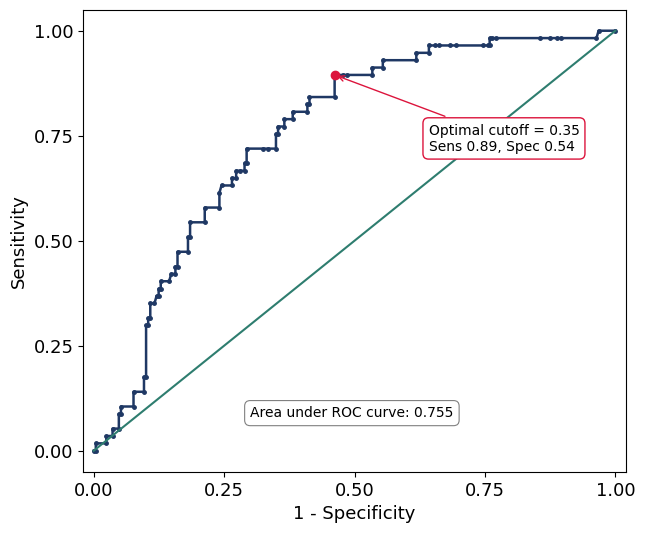

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings("ignore")
# Lasso model through the same four-feature pipeline
lasso_clf = LogisticRegression(penalty="l1", solver="liblinear",
                               class_weight="balanced", random_state=42)
lasso_pipe = Pipeline([("prep", prep_final), ("model", lasso_clf)])
probs_lasso = cross_val_predict(lasso_pipe, model_df[FINAL_FEATURES], y_geo,
                                cv=cv_geo, method="predict_proba")[:, 1]

fpr, tpr, thresholds = roc_curve(y_geo, probs_lasso)
roc_auc = auc(fpr, tpr)

# Youden-optimal threshold
youden = tpr - fpr
best_idx = np.argmax(youden)
best_threshold = thresholds[best_idx]
best_sens = tpr[best_idx]
best_spec = 1 - fpr[best_idx]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#1F3864", lw=1.8, marker="o", markersize=2.5)
plt.plot([0, 1], [0, 1], color="#2E7D6F", lw=1.5)

# Optimal point with boxed callout
plt.plot(fpr[best_idx], tpr[best_idx], "o", color="crimson", markersize=6)
plt.annotate(
    f"Optimal cutoff = {best_threshold:.2f}\nSens {best_sens:.2f}, Spec {best_spec:.2f}",
    xy=(fpr[best_idx], tpr[best_idx]),
    xytext=(fpr[best_idx] + 0.18, tpr[best_idx] - 0.18),
    arrowprops=dict(arrowstyle="->", color="crimson"), fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="crimson", linewidth=1),
)

plt.text(0.30, 0.08, f"Area under ROC curve: {roc_auc:.3f}",
         fontsize=10,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="grey", linewidth=0.8))

plt.xticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.yticks([0.00, 0.25, 0.50, 0.75, 1.00])
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.xlim(-0.02, 1.02)
plt

In [31]:
import warnings
warnings.filterwarnings("ignore")
# Elastic Net logistic regression — blends L1 (Lasso) and L2 (Ridge) penalties
elastic = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5,
                             max_iter=5000, class_weight="balanced", random_state=42)
elastic_pipe = Pipeline([("prep", prep_final), ("model", elastic)])
p = cross_val_predict(elastic_pipe, model_df[FINAL_FEATURES], y_geo,
                      cv=cv_geo, method="predict_proba")[:, 1]
print(f"Elastic Net AUC = {roc_auc_score(y_geo, p):.3f}")

Elastic Net AUC = 0.752


In [32]:
final_model=Pipeline([("prep", prep_final),
                      ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
final_model.fit(model_df[FINAL_FEATURES], Y_geo)
feat_names=final_model.named_steps["prep"].get_feature_names_out()
coefs=final_model.named_steps["model"].coef_[0]
odds_ratios=np.exp(coefs)
or_table=pd.DataFrame({"Feature": feat_names, "Coefficient": coefs,"Odds Ratio": odds_ratios,}).sort_values("Odds Ratio", ascending=False)
print(or_table.to_string(index=False))

             Feature  Coefficient  Odds Ratio
        cat__grade_3     0.733213    2.081758
cat__er_status_ihc_N     0.613958    1.847730
cat__pr_status_ihc_N     0.228396    1.256583
        cat__grade_1    -0.107682    0.897914
cat__pr_status_ihc_P    -0.227395    0.796606
      num__age_years    -0.259625    0.771341
cat__er_status_ihc_P    -0.612957    0.541747
        cat__grade_2    -0.624530    0.535513


In [33]:
final_model.fit(model_df[FINAL_FEATURES], Y_geo)
feat_names=final_model.named_steps["prep"].get_feature_names_out()
coefs=final_model.named_steps["model"].coef_[0]

coef_lookup=dict(zip(feat_names, coefs))
rows=[
    ("num__age_years", "Age", "per 1 SD increase", None),
    ("cat__er_status_ihc_N", "ER status", "Negative vs Positive", None),
    ("cat__pr_status_ihc_N", "PR status", "Negative vs Positive", None),
    ("cat__grade_3", "Grade", "Grade 3 vs Grade 1", None),
    ("cat__grade_2", "Grade", "Grade 2 vs Grade 1", None),]

table_rows=[]
for enc_name, variable, category, _ in rows:
    coef=coef_lookup.get(enc_name, np.nan)
    table_rows.append({
        "VARIABLE": variable,
        "Comparison": category,
        "Odds Ratio": f"{np.exp(coef):.2f}",})

or_clean=pd.DataFrame(table_rows)
print(or_clean.to_string(index=False))
or_clean.to_csv("odds_ratios.csv", index=False)
print("\nSaved odds_ratios.csv")
    



 VARIABLE           Comparison Odds Ratio
      Age    per 1 SD increase       0.77
ER status Negative vs Positive       1.85
PR status Negative vs Positive       1.26
    Grade   Grade 3 vs Grade 1       2.08
    Grade   Grade 2 vs Grade 1       0.54

Saved odds_ratios.csv


In [34]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import statsmodels.api as sm

# --- 1) Build a clean modeling dataframe with the 4 features + outcome ---
dat = model_df[FINAL_FEATURES + ["pcr"]].copy()

# Convert categoricals to 0/1 dummy columns, with an explicit reference category
# ER: reference = Positive (so the coefficient is for "Negative")
dat["ER_negative"]  = (dat["er_status_ihc"] == "N").astype(int)
dat["PR_negative"]  = (dat["pr_status_ihc"] == "N").astype(int)
# Grade: reference = Grade 1
dat["Grade_2"] = (dat["grade"] == "2").astype(int)
dat["Grade_3"] = (dat["grade"] == "3").astype(int)

# Standardise age (so its OR is per 1 SD, matching the sklearn model)
dat["Age_z"] = (dat["age_years"] - dat["age_years"].mean()) / dat["age_years"].std()

# --- 2) Assemble predictors (X) and outcome (y), drop any rows with missing ---
predictors = ["Age_z", "ER_negative", "PR_negative", "Grade_2", "Grade_3"]
model_data = dat[predictors + ["pcr"]].dropna()

X = sm.add_constant(model_data[predictors])   # add intercept term
y = model_data["pcr"].astype(int)

# --- 3) Fit logistic regression with statsmodels ---
logit = sm.Logit(y, X).fit(disp=False)

# --- 4) Build the publication table: OR, 95% CI, p-value ---
params = logit.params
conf = logit.conf_int()
conf.columns = ["low", "high"]

table = pd.DataFrame({
    "Odds Ratio": np.exp(params),
    "CI low":     np.exp(conf["low"]),
    "CI high":    np.exp(conf["high"]),
    "p-value":    logit.pvalues,
})

# Nice labels, drop the intercept from display
label_map = {
    "Age_z": "Age (per 1 SD)",
    "ER_negative": "ER negative (vs positive)",
    "PR_negative": "PR negative (vs positive)",
    "Grade_2": "Grade 2 (vs Grade 1)",
    "Grade_3": "Grade 3 (vs Grade 1)",
}
table = table.drop("const")
table.index = [label_map[i] for i in table.index]

# Format for display
pub = pd.DataFrame({
    "Variable": table.index,
    "Odds Ratio (95% CI)": [f"{r['Odds Ratio']:.2f} ({r['CI low']:.2f}–{r['CI high']:.2f})"
                            for _, r in table.iterrows()],
    "p-value": [f"{p:.3f}" if p >= 0.001 else "<0.001" for p in table["p-value"]],
})

print(pub.to_string(index=False))
pub.to_csv("odds_ratios_full.csv", index=False)
print("\nSaved odds_ratios_full.csv")

                 Variable Odds Ratio (95% CI) p-value
           Age (per 1 SD)    0.80 (0.58–1.09)   0.157
ER negative (vs positive)    3.61 (1.39–9.37)   0.008
PR negative (vs positive)    1.25 (0.49–3.20)   0.647
     Grade 2 (vs Grade 1)    0.62 (0.16–2.43)   0.497
     Grade 3 (vs Grade 1)    2.58 (0.82–8.07)   0.104

Saved odds_ratios_full.csv


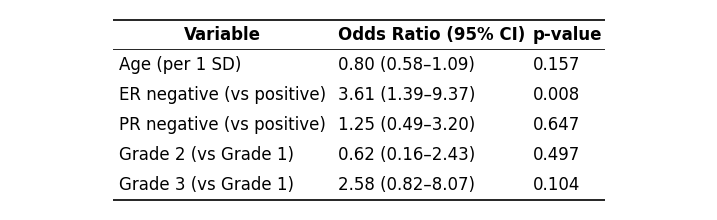

In [36]:
import matplotlib.pyplot as plt

# The finished publication table (from statsmodels)
table_data = [
    ["Age (per 1 SD)",            "0.80 (0.58–1.09)", "0.157"],
    ["ER negative (vs positive)", "3.61 (1.39–9.37)", "0.008"],
    ["PR negative (vs positive)", "1.25 (0.49–3.20)", "0.647"],
    ["Grade 2 (vs Grade 1)",      "0.62 (0.16–2.43)", "0.497"],
    ["Grade 3 (vs Grade 1)",      "2.58 (0.82–8.07)", "0.104"],
]
col_labels = ["Variable", "Odds Ratio (95% CI)", "p-value"]

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axis("off")

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc="left", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.8)
tbl.auto_set_column_width(col=[0, 1, 2])

n_rows = len(table_data) + 1   # +1 for header
n_cols = len(col_labels)

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)                       # remove all borders first
    cell.PAD = 0.03
    if row == 0:                                # header: bold, line above & below
        cell.set_text_props(fontweight="bold")
        cell.visible_edges = "TB"
        cell.set_linewidth(1.2)
    if row == n_rows - 1:                        # bottom rule under last row
        cell.visible_edges = "B"
        cell.set_linewidth(1.2)

plt.savefig("table2_oddsratios.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# --- Prepare the modeling dataframe (same encoding as before) ---
dat = model_df[FINAL_FEATURES + ["pcr"]].copy()
dat["ER_negative"] = (dat["er_status_ihc"] == "N").astype(int)
dat["PR_negative"] = (dat["pr_status_ihc"] == "N").astype(int)
dat["Grade_2"]     = (dat["grade"] == "2").astype(int)
dat["Grade_3"]     = (dat["grade"] == "3").astype(int)
dat["Age_z"]       = (dat["age_years"] - dat["age_years"].mean()) / dat["age_years"].std()

predictors = ["Age_z", "ER_negative", "PR_negative", "Grade_2", "Grade_3"]
labels = {
    "Age_z": "Age (per 1 SD)",
    "ER_negative": "ER negative (vs positive)",
    "PR_negative": "PR negative (vs positive)",
    "Grade_2": "Grade 2 (vs Grade 1)",
    "Grade_3": "Grade 3 (vs Grade 1)",
}

def fmt_or(coef, ci_low, ci_high, p):
    """Format one result as 'OR (low–high)' and a p-string."""
    or_str = f"{np.exp(coef):.2f} ({np.exp(ci_low):.2f}–{np.exp(ci_high):.2f})"
    p_str = f"{p:.3f}" if p >= 0.001 else "<0.001"
    return or_str, p_str

rows = []

# --- UNIVARIABLE: one model per predictor, alone ---
uni_results = {}
for pred in predictors:
    d = dat[[pred, "pcr"]].dropna()
    X = sm.add_constant(d[[pred]])
    y = d["pcr"].astype(int)
    m = sm.Logit(y, X).fit(disp=False)
    ci = m.conf_int().loc[pred]
    uni_results[pred] = fmt_or(m.params[pred], ci[0], ci[1], m.pvalues[pred])

# --- MULTIVARIABLE: all predictors together ---
d = dat[predictors + ["pcr"]].dropna()
Xm = sm.add_constant(d[predictors])
ym = d["pcr"].astype(int)
mm = sm.Logit(ym, Xm).fit(disp=False)

# --- Assemble the combined table ---
for pred in predictors:
    uni_or, uni_p = uni_results[pred]
    ci = mm.conf_int().loc[pred]
    multi_or, multi_p = fmt_or(mm.params[pred], ci[0], ci[1], mm.pvalues[pred])
    rows.append({
        "Variable": labels[pred],
        "Univariable OR (95% CI)": uni_or,
        "Uni p": uni_p,
        "Multivariable OR (95% CI)": multi_or,
        "Multi p": multi_p,
    })

table2 = pd.DataFrame(rows)
print(table2.to_string(index=False))
table2.to_csv("table2_full.csv", index=False)
print("\nSaved table2_full.csv")

                 Variable Univariable OR (95% CI)  Uni p Multivariable OR (95% CI) Multi p
           Age (per 1 SD)        0.77 (0.57–1.03)  0.081          0.80 (0.58–1.09)   0.157
ER negative (vs positive)       7.37 (3.70–14.67) <0.001          3.61 (1.39–9.37)   0.008
PR negative (vs positive)        4.37 (2.21–8.66) <0.001          1.25 (0.49–3.20)   0.647
     Grade 2 (vs Grade 1)        0.15 (0.06–0.36) <0.001          0.62 (0.16–2.43)   0.497
     Grade 3 (vs Grade 1)       6.77 (3.27–14.02) <0.001          2.58 (0.82–8.07)   0.104

Saved table2_full.csv


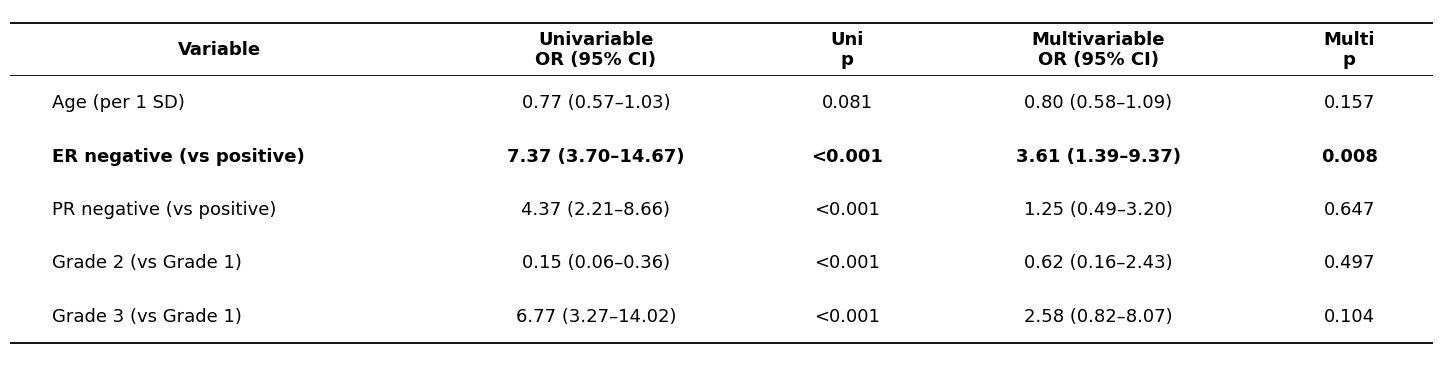

In [38]:
col_labels = ["Variable", "Univariable\nOR (95% CI)", "Uni\np",
              "Multivariable\nOR (95% CI)", "Multi\np"]
table_data = table2.values.tolist()

fig, ax = plt.subplots(figsize=(18, 4.5))      # wider + taller canvas
ax.axis("off")

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(13)
tbl.scale(1, 3.2)                              # much taller rows

# Wider columns with more space between them
col_widths = [0.30, 0.24, 0.12, 0.24, 0.12]
for (row, col), cell in tbl.get_celld().items():
    cell.set_width(col_widths[col])

n_rows = len(table_data) + 1

for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0)
    cell.PAD = 0.10                            # airy internal padding
    cell.set_text_props(ha="left" if col == 0 else "center")
    if row == 0:
        cell.set_text_props(fontweight="bold", ha="center")
        cell.visible_edges = "TB"
        cell.set_linewidth(1.3)
    if row == n_rows - 1:
        cell.visible_edges = "B"
        cell.set_linewidth(1.3)
    if row > 0 and table_data[row - 1][0].startswith("ER negative"):
        cell.set_text_props(fontweight="bold",
                            ha="left" if col == 0 else "center")

plt.savefig("table2_full.png", dpi=300, bbox_inches="tight")
plt.show()

Background dataset has 306 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=306 when initializing the masker.


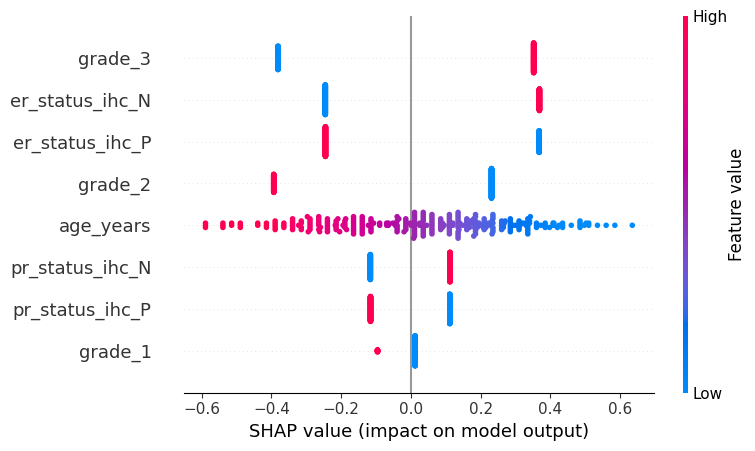

In [39]:
import shap
final_model=Pipeline([("prep", prep_final),
                     ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
final_model.fit(model_df[FINAL_FEATURES],Y_geo)
X_prep=final_model.named_steps["prep"].transform(model_df[FINAL_FEATURES])
feat_names=final_model.named_steps["prep"].get_feature_names_out()
clean_names=[n.replace("cat__", "").replace("num__", "") for n in feat_names]
explainer= shap.LinearExplainer(final_model.named_steps["model"], X_prep)
shap_values=explainer(X_prep)

plt.figure()
shap.summary_plot(shap_values, features=X_prep, feature_names=clean_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()


In [40]:
import os
print(os.getcwd())
print([f for f in os.listdir() if f.endswith('.xlsx')])

c:\Users\HP\Desktop\python
['algorithm_comparison_200.xlsx', 'Clinical_and_Other_Features.xlsx', 'data.xlsx', 'dca_results.xlsx', 'Extraction table updated.xlsx', 'paper2_benchmark_plan.xlsx', 'pCR_extraction_table_v3.xlsx', 'pCR_extraction_table_v5_final.xlsx']


In [41]:
files=[f for f in os.listdir() if f.endswith(".xlsx")]
for f in files:
    print(f)

algorithm_comparison_200.xlsx
Clinical_and_Other_Features.xlsx
data.xlsx
dca_results.xlsx
Extraction table updated.xlsx
paper2_benchmark_plan.xlsx
pCR_extraction_table_v3.xlsx
pCR_extraction_table_v5_final.xlsx


In [44]:
DUKE = "Clinical_and_Other_Features.xlsx"

# --- 1) Load the Data sheet; row 1 = column names, data starts at row 3 ---
raw = pd.read_excel(DUKE, sheet_name="Data", header=None)
duke = raw.iloc[3:].reset_index(drop=True)   # drop the two header rows + blank row

# --- 2) Pull the columns we need BY POSITION (robust against duplicate names) ---
resp  = pd.to_numeric(duke.iloc[:, 59], errors="coerce")   # Pathologic response
er    = pd.to_numeric(duke.iloc[:, 23], errors="coerce")   # ER  (0=neg,1=pos)
pr    = pd.to_numeric(duke.iloc[:, 24], errors="coerce")   # PR  (0=neg,1=pos)
grade = pd.to_numeric(duke.iloc[:, 34], errors="coerce")   # Nottingham grade 1/2/3
dob   = pd.to_numeric(duke.iloc[:, 19], errors="coerce")   # Date of Birth (Days)

# --- 3) Keep only assessable neoadjuvant patients (response 1,2,3,4; drop 5 & NA) ---
keep = resp.isin([1, 2, 3, 4])

# --- 4) Build the model-ready table, ALIGNED to the model's coding ---
duke_model = pd.DataFrame({
    "age_years":     (-dob / 365.25),                       # days -> age in years
    "er_status_ihc": er.map({1: "P", 0: "N"}),              # match GSE's P/N
    "pr_status_ihc": pr.map({1: "P", 0: "N"}),
    "grade":         grade.apply(lambda x: str(int(x)) if pd.notna(x) else np.nan),  # "1"/"2"/"3"
})

# --- 5) Outcome (STRICT: 1 = complete response = pCR, else non-pCR) ---
duke_model["pcr"] = (resp == 1).astype(int)
# (DCIS-allowed alternative: duke_model["pcr"] = resp.isin([1,3,4]).astype(int))

# apply the keep-filter to everything
duke_model = duke_model[keep].reset_index(drop=True)

print("Duke assessable patients:", len(duke_model))
print("pCR rate:", f"{duke_model['pcr'].mean():.1%}")
print("Missing per feature:")
print(duke_model[FINAL_FEATURES].isna().sum())

# --- 6) Validate the frozen model on Duke ---
final_model.fit(model_df[FINAL_FEATURES], y_geo)     # ensure it's trained on full dev data
X_duke = duke_model[FINAL_FEATURES]
y_duke = duke_model["pcr"].astype(int)
duke_probs = final_model.predict_proba(X_duke)[:, 1]

duke_auc = roc_auc_score(y_duke, duke_probs)
rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    i = rng.integers(0, len(y_duke), len(y_duke))
    if len(np.unique(y_duke.iloc[i])) == 2:
        boot.append(roc_auc_score(y_duke.iloc[i], duke_probs[i]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"\nExternal validation on Duke (n={len(y_duke)}):")
print(f"AUC = {duke_auc:.3f}  (95% CI {lo:.3f}\u2013{hi:.3f})")

Duke assessable patients: 300
pCR rate: 21.3%
Missing per feature:
age_years          0
er_status_ihc      0
pr_status_ihc      0
grade            101
dtype: int64

External validation on Duke (n=300):
AUC = 0.734  (95% CI 0.672–0.797)


In [45]:
assert len(duke_model) == 300 and duke_model['pcr'].sum() == 64, 'Duke cohort mismatch'

Method                     Brier       AUC
------------------------------------------
Raw (uncalibrated)        0.2003    0.7530
Platt (sigmoid)           0.1341    0.7534
Isotonic                  0.1396    0.7451


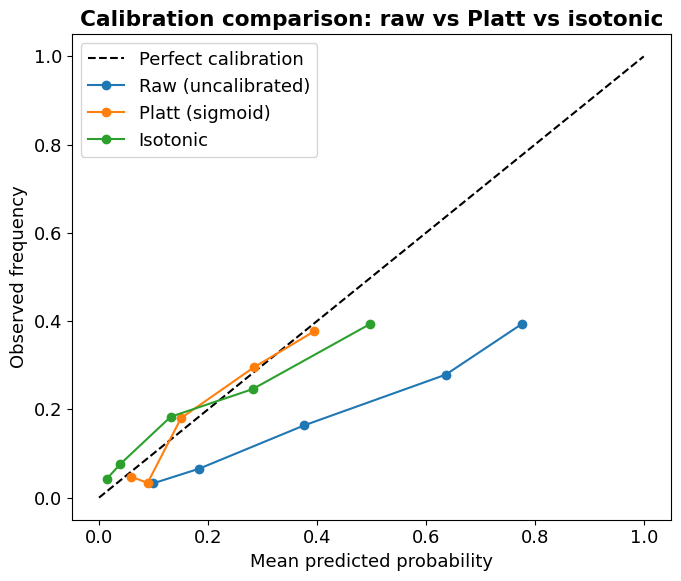

In [46]:
from sklearn.metrics import brier_score_loss, roc_auc_score
# The base pipeline (uncalibrated)
base = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

# Platt (sigmoid) and isotonic wrappers
platt    = CalibratedClassifierCV(base, method="sigmoid",  cv=5)
isotonic = CalibratedClassifierCV(base, method="isotonic", cv=5)

# Out-of-fold probabilities for each version, on the same CV
probs = {
    "Raw (uncalibrated)": cross_val_predict(base,     model_df[FINAL_FEATURES], y_geo, cv=cv_geo, method="predict_proba")[:, 1],
    "Platt (sigmoid)":    cross_val_predict(platt,    model_df[FINAL_FEATURES], y_geo, cv=cv_geo, method="predict_proba")[:, 1],
    "Isotonic":           cross_val_predict(isotonic, model_df[FINAL_FEATURES], y_geo, cv=cv_geo, method="predict_proba")[:, 1],
}

# Compare: Brier score (lower = better) and AUC (should be ~unchanged)
print(f"{'Method':<22}{'Brier':>10}{'AUC':>10}")
print("-" * 42)
for name, p in probs.items():
    print(f"{name:<22}{brier_score_loss(y_geo, p):>10.4f}{roc_auc_score(y_geo, p):>10.4f}")

# Plot all three calibration curves
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
for name, p in probs.items():
    obs, pred = calibration_curve(y_geo, p, n_bins=5, strategy="quantile")
    plt.plot(pred, obs, "o-", label=name)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration comparison: raw vs Platt vs isotonic", fontweight="bold")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("calibration_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [47]:
final_model.fit(model_df[FINAL_FEATURES], y_geo)
probs_duke = final_model.predict_proba(duke_model[FINAL_FEATURES])[:, 1]
y_duke = duke_model["pcr"].astype(int)

# find the best cutoff (Youden), then measure sensitivity & specificity there
fpr, tpr, thresholds = roc_curve(y_duke, probs_duke)
best = np.argmax(tpr - fpr)
cutoff = thresholds[best]

preds = (probs_duke >= cutoff).astype(int)
tn, fp, fn, tp = confusion_matrix(y_duke, preds).ravel()
sens = tp / (tp + fn)
spec = tn / (tn + fp)

print(f"Duke (n={len(y_duke)}):")
print(f"  Best cutoff = {cutoff:.2f}")
print(f"  Sensitivity = {sens:.2f}")
print(f"  Specificity = {spec:.2f}")

Duke (n=300):
  Best cutoff = 0.37
  Sensitivity = 0.86
  Specificity = 0.55


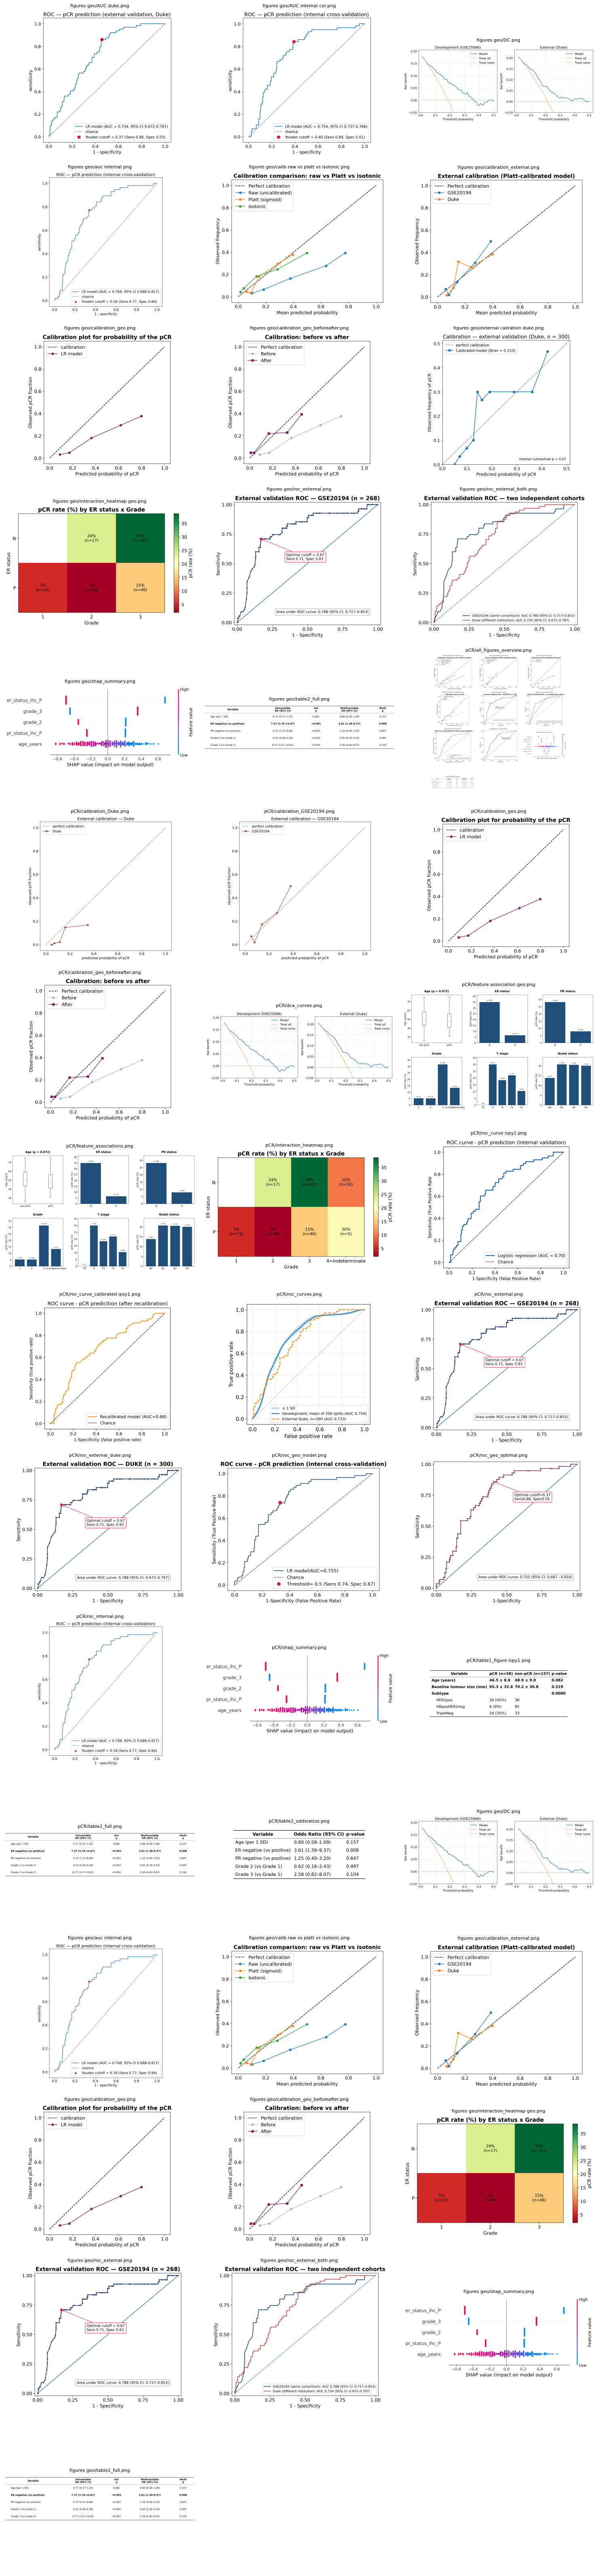

Combined 46 figures into all_figures_overview.png


In [48]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- the knobs you actually change ---
BASE = Path(r"C:\Users\HP\Desktop\pCR\figures geo")   # project folder (searched recursively)
COLS = 3                                   # figures per row
# -------------------------------------

EXTS = {".png", ".jpg", ".jpeg"}
OUTPUT = "all_figures_overview.png"

files = sorted(
    (p for p in BASE.rglob("*") if p.suffix.lower() in EXTS),
    key=lambda p: (str(p.parent), p.name)  # group by folder, then by name
)
if not files:
    raise SystemExit(f"No images found under {BASE.resolve()}")

n = len(files)
rows = math.ceil(n / COLS)

fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 5, rows * 4))
axes = axes.ravel()

for ax, file in zip(axes, files):
    ax.imshow(mpimg.imread(file))
    ax.set_title(f"{file.parent.name}/{file.name}", fontsize=8)  # folder + name
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUTPUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Combined {n} figures into {OUTPUT}")

In [49]:
for name, val in list(globals().items()):
    if isinstance(val, pd.DataFrame):
        print(name, "→", val.shape, "→", list(val.columns))

__ → (5, 0) → []
___ → (5, 24) → ['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue']
clin_geo → (508, 25) → ['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue'

In [50]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

Xdev, ydev = model_df[FINAL_FEATURES], y_geo
pipe = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000,
                                              class_weight="balanced"))])

scores = []
for seed in range(200):                                  # 200 different shuffles
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    s = cross_val_score(pipe, Xdev, ydev, cv=cv, scoring="roc_auc")
    scores.append(s.mean())                              # this seed's average AUC

scores = np.array(scores)
print(f"internal AUC = {scores.mean():.3f} "
      f"(SD {scores.std():.3f}, range {scores.min():.3f}-{scores.max():.3f})")

internal AUC = 0.764 (SD 0.007, range 0.739-0.780)


In [51]:
from sklearn.calibration import CalibratedClassifierCV

calib = CalibratedClassifierCV(
    Pipeline([("prep", prep_final),
              ("model", LogisticRegression(max_iter=1000,
                                           class_weight="balanced"))]),
    method="sigmoid", cv=5)
calib.fit(model_df[FINAL_FEATURES], y_geo)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step..._iter=1000))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [52]:
# before — raw probabilities, gives cutoff 0.37
oof = cross_val_predict(pipe, Xdev, ydev,
                        cv=StratifiedKFold(5, shuffle=True, random_state=42),
                        method="predict_proba")[:, 1]

# after — calibrated probabilities, gives cutoff ~0.18
oof = cross_val_predict(calib, Xdev, ydev,
                        cv=StratifiedKFold(5, shuffle=True, random_state=42),
                        method="predict_proba")[:, 1]

In [53]:
import numpy as np
from sklearn.metrics import roc_curve
for label, cut in [("Default", 0.50), ("Youden", None)]:
    fpr, tpr, thr = roc_curve(ydev, oof)          # oof = your reported probabilities
    if cut is None:
        j = np.argmax(tpr - fpr); sens, spec, cut = tpr[j], 1 - fpr[j], thr[j]
    else:
        pred = (oof >= cut); sens = ((pred == 1) & (ydev == 1)).sum() / (ydev == 1).sum()
        spec = ((pred == 0) & (ydev == 0)).sum() / (ydev == 0).sum()
    print(f"{label}: cutoff {cut:.2f}, Sens {sens:.2f}, Spec {spec:.2f}")

Default: cutoff 0.50, Sens 0.00, Spec 1.00
Youden: cutoff 0.14, Sens 0.88, Spec 0.57


In [ ]:
import numpy as np, pandas as pd
from scipy.stats import chi2

def hosmer_lemeshow(y_true, y_prob, g=10):
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    df["bin"] = pd.qcut(df["p"], g, duplicates="drop")   # g equal-sized risk groups
    grp = df.groupby("bin", observed=True)
    obs_1 = grp["y"].sum()                 # observed pCR per group
    exp_1 = grp["p"].sum()                 # expected pCR per group
    obs_0 = grp["y"].count() - obs_1
    exp_0 = grp["y"].count() - exp_1
    hl = (((obs_1 - exp_1) ** 2 / exp_1) + ((obs_0 - exp_0) ** 2 / exp_0)).sum()
    dof = len(obs_1) - 2
    p = 1 - chi2.cdf(hl, dof)
    return hl, p

oof_cal=cross_val_predict(calib, Xdev, ydev,
                          cv=StratifiedKFold(5, shuffle=True, random_state=0),
                          method="predict_proba")[:, 1]
ext={"Duke": duke_model}
# use the CALIBRATED probabilities (same scale as everything else you report)
print("Internal :", hosmer_lemeshow(ydev, oof_cal))
for name, d in ext.items():
    Xe, ye = d[["age_years","er_status_ihc","pr_status_ihc","grade"]], d["pcr"].values
    pe = calib.predict_proba(Xe)[:, 1]
    print(name, ":", hosmer_lemeshow(ye, pe))

Internal : (np.float64(6.3572240631493235), np.float64(0.6072841049668816))
Duke : (np.float64(17.913388421461825), np.float64(0.021885282465389677))


In [55]:
from sklearn.metrics import average_precision_score

def auc_pr_ci(y, p, n_boot=2000, seed=1):
    ap = average_precision_score(y, p)                 # area under precision-recall curve
    rs = np.random.default_rng(seed); boot = []
    for _ in range(n_boot):
        idx = rs.integers(0, len(y), len(y))           # resample patients
        if 0 < y[idx].sum() < len(idx):
            boot.append(average_precision_score(y[idx], p[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return ap, lo, hi, y.mean()                        # last value = baseline (prevalence)

# internal (out-of-fold, same calibrated probabilities you report elsewhere)
oof = cross_val_predict(calib, Xdev, ydev,
                        cv=StratifiedKFold(5, shuffle=True, random_state=42),
                        method="predict_proba")[:, 1]
ap, lo, hi, base = auc_pr_ci(np.asarray(ydev), oof)
print(f"Internal  AUC-PR {ap:.3f} ({lo:.3f}-{hi:.3f}) | baseline {base:.3f}")

# external cohorts
for name, d in ext.items():
    Xe, ye = d[["age_years","er_status_ihc","pr_status_ihc","grade"]], d["pcr"].values
    pe = calib.predict_proba(Xe)[:, 1]
    ap, lo, hi, base = auc_pr_ci(ye, pe)
    print(f"{name}: AUC-PR {ap:.3f} ({lo:.3f}-{hi:.3f}) | baseline {base:.3f}")

Internal  AUC-PR 0.342 (0.263-0.460) | baseline 0.186
Duke: AUC-PR 0.406 (0.305-0.526) | baseline 0.213


In [56]:
import os
os.makedirs("data", exist_ok=True)
model_df.to_csv("data/gse25066.csv", index=False)
duke_model.to_csv("data/duke.csv", index=False)
print("saved")

saved


In [57]:
print(model_df.columns.tolist())

['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue', 'pcr']


In [58]:
print(model_df["set_class"].value_counts(dropna=False))

set_class
SET-Low     258
SET-Int      28
SET-High     20
Name: count, dtype: int64


In [59]:
print(model_df.columns.tolist())

['sample id', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue', 'pcr']


In [60]:
print(model_df['pathologic_response_rcb_class'].value_counts(dropna=False))
print()
print(pd.crosstab(model_df['pathologic_response_rcb_class'],
                  model_df['pcr'],
                  dropna=False))

pathologic_response_rcb_class
RCB-II     136
RCB-0/I     86
RCB-III     79
NA           5
Name: count, dtype: int64

pcr                            0.0  1.0
pathologic_response_rcb_class          
NA                               5    0
RCB-0/I                         29   57
RCB-II                         136    0
RCB-III                         79    0


In [61]:
rcb_map = {'RCB-0/I': 1, 'RCB-II': 2, 'RCB-III': 3}

df = model_df[model_df['pathologic_response_rcb_class'].isin(rcb_map)].copy()

df['rcb_ordinal'] = df['pathologic_response_rcb_class'].map(rcb_map)
df.loc[df['pcr'] == 1, 'rcb_ordinal'] = 0

df['label_pcr']     = (df['rcb_ordinal'] == 0).astype(int)
df['label_rcb01']   = (df['rcb_ordinal'] <= 1).astype(int)
df['label_not_III'] = (df['rcb_ordinal'] <= 2).astype(int)

print(df['rcb_ordinal'].value_counts().sort_index())
print()
for col in ['label_pcr', 'label_rcb01', 'label_not_III']:
    print(col, int(df[col].sum()), 'positives out of', len(df))

rcb_ordinal
0     57
1     29
2    136
3     79
Name: count, dtype: int64

label_pcr 57 positives out of 301
label_rcb01 86 positives out of 301
label_not_III 222 positives out of 301


In [62]:
NUM = ['age_years']
CAT = ['er_status_ihc', 'pr_status_ihc', 'grade']
LABELS = ['label_pcr', 'label_rcb01', 'label_not_III']

def make_model():
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), NUM),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh',  OneHotEncoder(drop='first', handle_unknown='ignore'))]), CAT),
    ])
    return Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000))])

X = df[NUM + CAT]
y_eval = df['label_pcr'].values

rows = []
for seed in range(50):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for tr, te in cv.split(X, y_eval):
        for lab in LABELS:
            m = make_model().fit(X.iloc[tr], df[lab].values[tr])
            p = m.predict_proba(X.iloc[te])[:, 1]
            rows.append({'label': lab,
                         'auc': roc_auc_score(y_eval[te], p),
                         'ap':  average_precision_score(y_eval[te], p)})

res = pd.DataFrame(rows)
print(res.groupby('label')[['auc', 'ap']].agg(['mean', 'std']).round(3))

                 auc            ap       
                mean    std   mean    std
label                                    
label_not_III  0.631  0.116  0.296  0.089
label_pcr      0.768  0.064  0.414  0.102
label_rcb01    0.770  0.064  0.416  0.103


In [63]:
res['fold_id']=res.index// len(LABELS)
w= res.pivot(index='fold_id', columns='label', values='auc')

for a, b in [('label_rcb01', 'label_pcr'), ('label_not_III', 'label_pcr')]:
    d=w[a] - w[b]
    print(f'{a} vs {b}: mean {d.mean():+.4f} sd{d.std():.4f} wins{(d > 0).mean():.0%} of folds')
             

label_rcb01 vs label_pcr: mean +0.0022 sd0.0147 wins55% of folds
label_not_III vs label_pcr: mean -0.1366 sd0.1181 wins7% of folds


In [64]:
rows2=[]
for seed in range(50):
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for tr, tr in cv.split(X, y_eval):
        for lab in LABELS:
            y_lab=df[lab].values
            m=make_model().fit(X.iloc[tr], y_lab[tr])
            p=m.predict_proba(X.iloc[te])[:,1]
            rows2.append({
                'label': lab,
                'auc_on_pcr': roc_auc_score(y_eval[te], p),
                'auc_on_self': roc_auc_score(y_lab[te],p),
            })

res2=pd.DataFrame(rows2)
print(res2.groupby('label')[['auc_on_pcr','auc_on_self']].mean().round(3))


               auc_on_pcr  auc_on_self
label                                 
label_not_III       0.563        0.531
label_pcr           0.750        0.750
label_rcb01         0.742        0.670


In [65]:
print(df.shape, X.shape, len(y_eval), int(y_eval.sum()))
print(df[LABELS].sum().to_dict())
print(NUM+CAT)

(301, 29) (301, 4) 301 57
{'label_pcr': 57, 'label_rcb01': 86, 'label_not_III': 222}
['age_years', 'er_status_ihc', 'pr_status_ihc', 'grade']


In [66]:
def run(score_self=False):
    out = []
    for seed in range(50):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        for tr, te in cv.split(X, y_eval):
            for lab in LABELS:
                y_lab = df[lab].values
                m = make_model().fit(X.iloc[tr], y_lab[tr])
                p = m.predict_proba(X.iloc[te])[:, 1]
                out.append({'label': lab,
                            'auc': roc_auc_score(y_eval[te], p),
                            'self': roc_auc_score(y_lab[te], p) if score_self else None})
    return pd.DataFrame(out)

a = run(score_self=False)
b = run(score_self=True)
print(a.groupby('label')['auc'].mean().round(3))
print()
print(b.groupby('label')[['auc', 'self']].mean().round(3))

label
label_not_III    0.631
label_pcr        0.768
label_rcb01      0.770
Name: auc, dtype: float64

                 auc   self
label                      
label_not_III  0.631  0.476
label_pcr      0.768  0.768
label_rcb01    0.770  0.711


In [67]:
import os
print([f for f in os.listdir('.') if 'GSE' in f])

['GSE25066_series_matrix.txt', 'GSE25066_series_matrix.txt.gz']


In [68]:
print(os.path.isdir('GSE25066_series_matrix.txt'))
print(os.listdir('GSE25066_series_matrix.txt'))

True
['GSE25066_series_matrix.txt']


In [69]:
PATH= os.path.join('GSE25066_series_matrix.txt', 'GSE25066_series_matrix.txt')

with open(PATH) as f:
    for line in f:
        if line.startswith('!series_matrix_table_begin'):
            header=next(f)
            first=next(f)
            print('samples:', len(header.split('\t')) - 1)
            print('first gene:', first.split('\t')[0])
            break

samples: 508
first gene: "1007_s_at"


In [70]:
expr=pd.read_csv(PATH, sep='\t', comment='!', index_col=0)
print(expr.shape)
print(expr.columns[:3].tolist())

(22283, 508)
['GSM615096', 'GSM615097', 'GSM615098']


In [71]:
print(df['sample id'].head(3).tolist())

['1002', '1009', '1011']


In [72]:
with open(PATH) as f:
    for line in f:
        if line.startswith('!Sample_title'):
            parts=line.strip().split('\t')
            print(len(parts) - 1, 'titles')
            print(parts[1:4])
            break

508 titles
['"1002"', '"1005"', '"1009"']


In [73]:
def get_line(path, key):
    with open(path) as f:
        for line in f:
            if line.startswith(key):
                return[p.strip().strip('"') for p in line.strip().split('\t')[1:]]
            
titles=get_line(PATH, '!Sample_title')
gsms=get_line(PATH, '!Sample_geo_accession')

id_to_gsm=dict(zip(titles, gsms))

print(len(id_to_gsm))
print(id_to_gsm['1002'])

508
GSM615096


In [74]:
df=df[df['sample id'].isin(id_to_gsm)].copy()
df['gsm']=df['sample id'].map(id_to_gsm)

expr_matched=expr[df['gsm'].tolist()]

print(df.shape, expr_matched.shape)
print((expr_matched.columns==df['gsm']).all())

(301, 30) (22283, 301)
True


In [75]:
X_clin=df[NUM+CAT]

X_expr=expr_matched.T
X_expr.index=X_clin.index

y_resp=df['label_pcr'].values
y_resist=(df['rcb_ordinal']==3).astype(int).values

print(X_clin.shape, X_expr.shape)
print('response positives:', y_resp.sum())
print('resistance positives:', y_resist.sum())

(301, 4) (301, 22283)
response positives: 57
resistance positives: 79


In [76]:
from sklearn.feature_selection import SelectKBest, f_classif

GENES= X_expr.columns.tolist()
X_all= pd.concat([X_clin, X_expr], axis=1)

num_pipe= Pipeline([('imp', SimpleImputer(strategy='median')), ('sc' ,StandardScaler())])
cat_pipe= Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('oh', OneHotEncoder(drop='first', handle_unknown='ignore'))])
gen_pipe= Pipeline([('sc', StandardScaler()), ('sel', SelectKBest(f_classif, k=200))])

def model(use_genes):
    blocks=[('num', num_pipe, NUM), ('cat', cat_pipe, CAT)]
    if use_genes:
        blocks.append(('gen', gen_pipe, GENES))
    return Pipeline ([('pre', ColumnTransformer(blocks)),
                      ('clf', LogisticRegression(max_iter=2000))])  

strata=df['rcb_ordinal'].values
targets={'response': y_resp, 'resistance': y_resist}

rows3=[]
for seed in range(50):
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for tr, te in cv.split(X_all, strata):
        for tname, y in targets.items():
            for use_genes in [False, True]:
                m=model(use_genes).fit(X_all.iloc[tr], y[tr])
                p=m.predict_proba(X_all.iloc[te])[:,1]
                rows3.append({'target': tname,
                              'features': 'clin+genes' if use_genes else'clin',
                              'auc': roc_auc_score(y[te], p)})
                
res3= pd.DataFrame(rows3)
print(res3.groupby(['target', 'features'])['auc'].mean().round(3))

target      features  
resistance  clin          0.479
            clin+genes    0.617
response    clin          0.767
            clin+genes    0.750
Name: auc, dtype: float64


In [77]:
res3['fold_id'] = res3.index // 4
w = res3.pivot_table(index='fold_id', columns=['target', 'features'], values='auc')

for t in ['resistance', 'response']:
    d = w[(t, 'clin+genes')] - w[(t, 'clin')]
    print(f'{t}: mean {d.mean():+.3f}  wins {(d > 0).mean():.0%} of folds')

resistance: mean +0.138  wins 91% of folds
response: mean -0.017  wins 43% of folds


In [78]:
print(DUKE)
duke_df= pd.read_excel(DUKE)
print(duke_df.shape)

Clinical_and_Other_Features.xlsx


(924, 98)


In [79]:
cols = [c for c in duke_df.columns if any(k in c.lower() for k in ['rcb', 'residual', 'burden', 'response'])]
print(cols)

['Tumor Response', 'Pathologic Response to Neoadjuvant Therapy', 'Near Complete Response']


In [80]:
for c in ['Tumor Response', 'Pathologic Response to Neoadjuvant Therapy', 'Near Complete Response']:
    print('---', c)
    print(duke_df[c].value_counts(dropna=False))

--- Tumor Response
Tumor Response
NaN                                                                                                                                                                                                           610
2                                                                                                                                                                                                             214
1                                                                                                                                                                                                              52
3                                                                                                                                                                                                              46
Clinical Response, Evaluated Through Imaging                                                                                  

In [81]:
print(df['source'].value_counts(dropna=False))
print(df['tissue'].value_counts(dropna=False))

source
MDACC    227
ISPY      74
Name: count, dtype: int64
tissue
NaN                    224
breast cancer tumor     77
Name: count, dtype: int64


In [82]:
print(pd.crosstab(df['source'], df['rcb_ordinal']))

rcb_ordinal   0   1    2   3
source                      
ISPY         14   3   36  21
MDACC        43  26  100  58


In [83]:
import glob, os
hits=glob.glob(os.path.join(os.path.expanduser('~'), '**', '*spy*'), recursive= True)
print(hits[:20])

['C:\\Users\\HP\\AppData\\Local\\Packages\\JASP.STANDALONE_093qj5q4tr2cw\\LocalCache\\Local\\JASP-Stats-MSIX\\JASPDesktop\\BundledJASPModules_0.97.1.0_4feb7b3_Jun3202616-09-46(Netherlands)\\module_libs\\jaspAcceptanceSampling\\bslib\\lib\\bs3\\assets\\javascripts\\bootstrap\\scrollspy.js', 'C:\\Users\\HP\\AppData\\Local\\Packages\\JASP.STANDALONE_093qj5q4tr2cw\\LocalCache\\Local\\JASP-Stats-MSIX\\JASPDesktop\\BundledJASPModules_0.97.1.0_4feb7b3_Jun3202616-09-46(Netherlands)\\module_libs\\jaspAnova\\bslib\\lib\\bs3\\assets\\javascripts\\bootstrap\\scrollspy.js', 'C:\\Users\\HP\\AppData\\Local\\Packages\\JASP.STANDALONE_093qj5q4tr2cw\\LocalCache\\Local\\JASP-Stats-MSIX\\JASPDesktop\\BundledJASPModules_0.97.1.0_4feb7b3_Jun3202616-09-46(Netherlands)\\module_libs\\jaspAudit\\bslib\\lib\\bs3\\assets\\javascripts\\bootstrap\\scrollspy.js', 'C:\\Users\\HP\\AppData\\Local\\Packages\\JASP.STANDALONE_093qj5q4tr2cw\\LocalCache\\Local\\JASP-Stats-MSIX\\JASPDesktop\\BundledJASPModules_0.97.1.0_4feb7

In [84]:
import os , glob
print(os.getcwd())
print(glob.glob('*'))      

c:\Users\HP\Desktop\python
['14 studies.png', '1571306559 paper (1).docx', '1571306559 paper (1).pdf', '1571306559 paper.pdf', 'A Parsimonious and Externally Validated Clinical Model for Predicting Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer.docx', 'A Predictive Model for Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer (1).pdf', 'A Predictive Model for Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer (2).docx', 'A Predictive Model for Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer (2).pdf', 'A Predictive Model for Pathological Complete Response to Neoadjuvant Chemotherapy in Breast Cancer.pdf', 'AI-Part 1 (2).pdf', 'algorithm_comparison_200.xlsx', 'all_figures_overview.png', 'arch_figure_editable.pdf', 'arch_figure_editable.pptx', 'arch_figure_editable_page-0001.jpg', 'ARTCLE 1 (Chaimaa).docx', 'ARTICLE_14refs.docx', 'bp gq.pdf', 'brewlab 3 (1).pptx', 'brewlab 3.pptx', 'c

In [85]:
#load the development clinical data
df=pd.read_pickle("clin_geo.pkl")

#show ALL available columns 
print("ALL GSE25066 columns:") 
for c in df.columns: 
    print("  -", c)

ALL GSE25066 columns:
  - sample id
  - source
  - age_years
  - er_status_ihc
  - pr_status_ihc
  - her2_status
  - er_status_ihc_esr1_for indeterminate
  - clinical_t_stage
  - clinical_nodal_status
  - clinical_ajcc_stage
  - grade
  - pathologic_response_pcr_rd
  - pathologic_response_rcb_class
  - drfs_1_event_0_censored
  - drfs_even_time_years
  - esr1_status
  - erbb2_status
  - set_class
  - chemosensitivity_prediction
  - ggi_class
  - pam50_class
  - dlda30_prediction
  - rcb_0_i_prediction
  - tissue


In [86]:
df=pd.read_pickle("clin_geo.pkl")

for col in ["her2_status", "erbb2_status", "pam50_class"]:
    print(f"\n==={col}===")
    print(df[col].value_counts(dropna=False))


===her2_status===
her2_status
N     485
NA     13
P       6
I       4
Name: count, dtype: int64

===erbb2_status===
erbb2_status
N    479
P     29
Name: count, dtype: int64

===pam50_class===
pam50_class
Basal     189
LumA      160
LumB       78
Normal     44
Her2       37
Name: count, dtype: int64


In [87]:
df= pd.read_pickle("clin_geo.pkl")

#outcome: pCR =1, RD =0
y=df["pathologic_response_pcr_rd"].map({"pCR":1, "RD": 0})
keep=y.notna()
df, y= df[keep].copy(), y[keep].astype(int)

#clean age to numeric
df["age_years"]= pd.to_numeric(df["age_years"], errors="coerce")

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_auc(features, num, cat):
    prep=ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])

    pipe=Pipeline([("prep", prep),
                   ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
    p=cross_val_predict(pipe, df[features], y, cv=cv, method="predict_proba")[:,1]
    return roc_auc_score(y, p)

#four features (baseline)
base=cv_auc(["age_years", "er_status_ihc", "pr_status_ihc","grade"],
            ["age_years"], ["er_status_ihc", "pr_status_ihc", "grade"])

#four features + PAM50 subtype
withpam=cv_auc(["age_years", "er_status_ihc", "pr_status_ihc", "grade", "pam50_class"],
               ["age_years"], ["er_status_ihc", "pr_status_ihc", "grade", "pam50_class"]) 

print(f"AUC, 4 clinical features: {base:.3f}")
print(f"AUC, + PAM50 molecular subtype: {withpam:.3f}")

AUC, 4 clinical features: 0.742
AUC, + PAM50 molecular subtype: 0.750


In [88]:
for name, v in list(globals().items()):
    if name.startswith('_'):
        continue
    if isinstance(v, (np.ndarray, pd.Series, list)):
        try:
            a = np.asarray(v).ravel()
        except Exception:
            continue
        if a.size < 50 or a.dtype.kind not in 'ifb':
            continue
        u = np.unique(a[~pd.isna(a)])
        kind = 'LABEL' if set(u).issubset({0, 1}) else (
               'PROB'  if a.min() >= 0 and a.max() <= 1 else '')
        if kind:
            print(f'{kind:6} {name:35} n={a.size:5}  min={a.min():.3f} max={a.max():.3f}')

LABEL  y_geo                               n=  306  min=0.000 max=1.000
PROB   p                                   n=   60  min=0.000 max=0.987
LABEL  Y_geo                               n=  306  min=0.000 max=1.000
PROB   probs_geo                           n=  306  min=0.025 max=0.866
PROB   boot                                n= 2000  min=0.630 max=0.834
LABEL  pred                                n=  306  min=0.000 max=1.000
PROB   fpr                                 n=  101  min=0.000 max=1.000
PROB   tpr                                 n=  101  min=0.000 max=1.000
PROB   cal_probs_geo                       n=  306  min=0.000 max=0.567
PROB   probs_lasso                         n=  306  min=0.054 max=0.867
LABEL  y                                   n=  306  min=0.000 max=1.000
LABEL  ym                                  n=  306  min=0.000 max=1.000
LABEL  er                                  n=  922  min=0.000 max=1.000
LABEL  pr                                  n=  922  min=0.000 ma

In [89]:
import numpy as np, pandas as pd

# 1. are the 306-length labels the same array?
for a, b in [('y_geo','ydev'), ('y_geo','y'), ('y_geo','ym')]:
    print(a, 'vs', b, ':', np.array_equal(np.asarray(globals()[a]), np.asarray(globals()[b])))

# 2. do oof_cal and oof differ?
print('oof_cal == oof :', np.array_equal(np.asarray(oof_cal), np.asarray(oof)))

# 3. sanity: AUC of each internal probability against y_geo
from sklearn.metrics import roc_auc_score
for nm in ['oof_cal','oof_raw','cal_probs_geo','probs_geo','p_int','p']:
    try:
        print(f'{nm:16} AUC={roc_auc_score(y_geo, globals()[nm]):.3f}  prev={np.mean(y_geo):.3f}')
    except Exception as e:
        print(nm, 'failed:', e)

# 4. hunt for the Duke n=300 subset in any DataFrame
for nm, v in list(globals().items()):
    if isinstance(v, pd.DataFrame) and not nm.startswith('_'):
        print(f'{nm:22} shape={v.shape}')

y_geo vs ydev : True
y_geo vs y : True
y_geo vs ym : True
oof_cal == oof : False
oof_cal          AUC=0.758  prev=0.186
oof_raw failed: 'oof_raw'
cal_probs_geo    AUC=0.749  prev=0.186
probs_geo        AUC=0.755  prev=0.186
p_int failed: 'p_int'
p failed: Found input variables with inconsistent numbers of samples: [306, 60]
clin_geo               shape=(508, 25)
geo                    shape=(306, 25)
model_df               shape=(306, 25)
sub                    shape=(296, 3)
table                  shape=(5, 4)
rate_grid              shape=(2, 4)
count_grid             shape=(2, 4)
X_geo                  shape=(306, 6)
or_table               shape=(8, 3)
or_clean               shape=(5, 3)
dat                    shape=(306, 10)
model_data             shape=(306, 6)
X                      shape=(301, 4)
conf                   shape=(6, 2)
pub                    shape=(5, 3)
Xm                     shape=(306, 6)
table2                 shape=(5, 5)
raw                    shape=(925, 98)
d

In [90]:
y_dev = np.asarray(y_geo)
p_dev_calibrated = cross_val_predict(calib, Xdev, ydev,
                                     cv=StratifiedKFold(5, shuffle=True, random_state=0),
                                     method="predict_proba")[:, 1]
y_duke = np.asarray(duke_model["pcr"])
p_duke_calibrated = calib.predict_proba(duke_model[FINAL_FEATURES])[:, 1]

 threshold  pct_spared  net_reduction_pct  sensitivity  specificity
      0.01    0.000000           0.000000     1.000000     0.000000
      0.02    0.000000           0.000000     1.000000     0.000000
      0.03    0.000000           0.000000     1.000000     0.000000
      0.04    0.000000           0.000000     1.000000     0.000000
      0.05    2.000000           2.000000     1.000000     0.025424
      0.06    5.000000           5.000000     1.000000     0.063559
      0.07   11.666667          11.666667     1.000000     0.148305
      0.08   18.333333          17.971014     0.984375     0.228814
      0.09   21.333333          20.600733     0.968750     0.262712
      0.10   23.666667          22.925926     0.968750     0.292373
      0.11   27.666667          26.917603     0.968750     0.343220
      0.12   30.000000          28.863636     0.953125     0.368644
      0.13   36.000000          34.467433     0.937500     0.440678
      0.14   43.000000          39.899225     0.

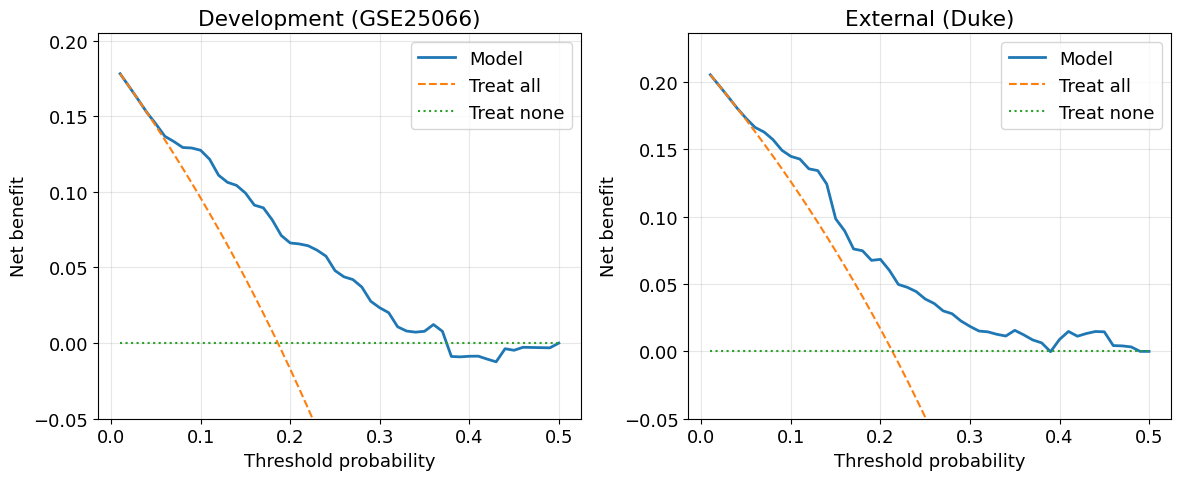

In [91]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
def net_benefit (y_true, y_prob, thresholds):
    """Standard DCA. Decision=TREAT when predicted probability >= threshold."""
    y_true= np.asarray(y_true)
    y_prob= np.asarray(y_prob)
    n= len(y_true)
    prev= y_true.mean()

    nb_model, nb_all= [], []
    for pt in thresholds:
        w=pt / (1 - pt)
        pos= y_prob >= pt
        tp=np.sum(pos & (y_true == 1))
        fp= np.sum(pos & (y_true == 0))
        nb_model.append(tp / n - (fp / n) * w)
        nb_all.append(prev - (1 - prev) * w)
    return np.array (nb_model), np.array(nb_all), np.zeros(len(thresholds))

def net_reduction (y_true, y_prob, thresholds):
    """Zhao framing. Decision = SPARE chemotherapy when probability < threshold."""
    y_true= np.asarray(y_true)
    y_prob= np.asarray(y_prob)
    n= len(y_true)
    n_pos= max(np.sum(y_true==1), 1)
    n_neg= max(np.sum(y_true==0), 1)

    rows = []
    for pt in thresholds:
        w= pt / (1 - pt)
        spared= y_prob < pt
        tn=np.sum(spared & (y_true == 0))
        fn = np.sum(spared & (y_true == 1))
        rows.append({
            'threshold': round(pt, 3),
            'pct_spared': 100 * spared.mean(),
            'net_reduction_pct': 100 * (tn / n - (fn / n) * w),
            'sensitivity': np.sum(~spared & (y_true == 1)) / n_pos,
            'specificity': tn / n_neg,
        })
    return pd.DataFrame(rows)


def run(cohorts, thresholds=np.arange(0.01, 0.51, 0.01)):
    """cohorts: {'name': (y_true, y_prob_calibrated), ...}"""
    fig, axes = plt.subplots(1, len(cohorts), figsize=(6 * len(cohorts), 5))
    axes = np.atleast_1d(axes)

    tables = {}
    for ax, (name, (y, p)) in zip(axes, cohorts.items()):
        nb_m, nb_a, nb_n = net_benefit(y, p, thresholds)
        ax.plot(thresholds, nb_m, lw=2, label='Model')
        ax.plot(thresholds, nb_a, ls='--', label='Treat all')
        ax.plot(thresholds, nb_n, ls=':', label='Treat none')
        ax.set_xlabel('Threshold probability')
        ax.set_ylabel('Net benefit')
        ax.set_title(name)
        ax.set_ylim(-0.05, max(nb_m.max(), nb_a.max()) * 1.15)
        ax.legend()
        ax.grid(alpha=0.3)
        tables[name] = net_reduction(y, p, thresholds)

    plt.tight_layout()
    plt.savefig('dca_curves.png', dpi=300)

    with pd.ExcelWriter('dca_results.xlsx') as w:
        for name, t in tables.items():
            t.to_excel(w, sheet_name=name[:30], index=False)

    return tables


# ---- edit these two lines only ----
tables = run({
    'Development (GSE25066)': (y_dev,  p_dev_calibrated),
    'External (Duke)':        (y_duke, p_duke_calibrated),
})

print(tables['External (Duke)'].head(20).to_string(index=False))

In [92]:
def net_benefit(y_true, y_prob, thresholds):
    """Standard DCA. Decision = TREAT when predicted probability >= threshold."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    prev = y_true.mean()

    nb_model, nb_all = [], []
    for pt in thresholds:
        w = pt / (1 - pt)
        pos = y_prob >= pt
        tp = np.sum(pos & (y_true == 1))
        fp = np.sum(pos & (y_true == 0))
        nb_model.append(tp / n - (fp / n) * w)
        nb_all.append(prev - (1 - prev) * w)

    return np.array(nb_model), np.array(nb_all), np.zeros(len(thresholds))


def net_reduction(y_true, y_prob, thresholds):
    """Zhao framing. Decision = SPARE chemotherapy when probability < threshold."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    n_pos = max(np.sum(y_true == 1), 1)
    n_neg = max(np.sum(y_true == 0), 1)

    rows = []
    for pt in thresholds:
        w = pt / (1 - pt)
        spared = y_prob < pt
        tn = np.sum(spared & (y_true == 0))
        fn = np.sum(spared & (y_true == 1))
        rows.append({
            'threshold': round(pt, 3),
            'pct_spared': 100 * spared.mean(),
            'net_reduction_pct': 100 * (tn / n - (fn / n) * w),
            'sensitivity': np.sum(~spared & (y_true == 1)) / n_pos,
            'specificity': tn / n_neg,
        })
    return pd.DataFrame(rows)

 threshold  pct_spared  net_reduction_pct  sensitivity  specificity
      0.01    0.000000           0.000000     1.000000     0.000000
      0.02    0.000000           0.000000     1.000000     0.000000
      0.03    0.000000           0.000000     1.000000     0.000000
      0.04    0.000000           0.000000     1.000000     0.000000
      0.05    2.614379           2.614379     1.000000     0.032129
      0.06    9.150327           8.802670     0.982456     0.108434
      0.07   20.261438          19.558648     0.964912     0.240964
      0.08   28.104575          27.038932     0.947368     0.333333
      0.09   34.313725          33.236371     0.947368     0.409639
      0.10   38.235294          37.145969     0.947368     0.457831
      0.11   40.849673          39.380921     0.929825     0.485944
      0.12   42.483660          40.255496     0.894737     0.497992
      0.13   45.424837          42.795432     0.877193     0.530120
      0.14   49.673203          46.633227     0.

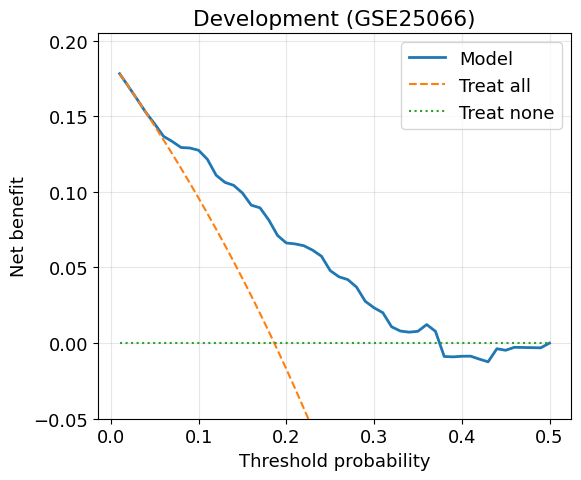

In [93]:
tables = run({'Development (GSE25066)': (y_geo, oof_cal)})
t = tables['Development (GSE25066)']
print(t.to_string(index=False))

In [94]:
print(t[t.threshold.isin([0.05,0.07,0.10,0.15,0.20,0.25])].to_string(index=False))

 threshold  pct_spared  net_reduction_pct  sensitivity  specificity
      0.05    2.614379           2.614379     1.000000     0.032129
      0.07   20.261438          19.558648     0.964912     0.240964
      0.10   38.235294          37.145969     0.947368     0.457831
      0.15   51.633987          48.173779     0.842105     0.598394
      0.20   61.111111          54.166667     0.701754     0.682731
      0.25   64.705882          56.427015     0.666667     0.718876


In [95]:
# what's in the modelling frame
print(duke_model.columns.tolist())
print(duke_model.dtypes, '\n')
for c in duke_model.columns:
    vc = duke_model[c].value_counts(dropna=False)
    if len(vc) <= 10:
        print(c, dict(vc), '\n')

# find the response column in the full Duke file
import re
pat = re.compile(r'(pcr|complete|response|resp|rcb|miller|payne|path)', re.I)
hits = [c for c in duke_df.columns if pat.search(str(c))]
print('candidate response columns:')
for c in hits:
    print(' ', c, '->', dict(duke_df[c].value_counts(dropna=False).head(8)))

['age_years', 'er_status_ihc', 'pr_status_ihc', 'grade', 'pcr']
age_years        float64
er_status_ihc        str
pr_status_ihc        str
grade                str
pcr                int64
dtype: object 

er_status_ihc {'P': np.int64(183), 'N': np.int64(117)} 

pr_status_ihc {'N': np.int64(152), 'P': np.int64(148)} 

grade {'3': np.int64(101), nan: np.int64(101), '2': np.int64(87), '1': np.int64(11)} 

pcr {0: np.int64(236), 1: np.int64(64)} 

candidate response columns:
  Tumor Response -> {nan: np.int64(610), 2: np.int64(214), 1: np.int64(52), 3: np.int64(46), 'Clinical Response, Evaluated Through Imaging ': np.int64(1), '{1=complete response on imaging, 2=not complete response, 3=imaging to assess treatment response is unavailable, NA=no neoadjuvant therapy or not enough information to assess neoadjuvant therapy status}': np.int64(1)}
  Pathologic Response to Neoadjuvant Therapy -> {nan: np.int64(653), 1: np.int64(124), 2: np.int64(61), -1: np.int64(31), 0: np.int64(24), 3: np.int64

In [96]:
import numpy as np, pandas as pd

# 1. what fitted objects are in memory?
for nm, v in list(globals().items()):
    if nm.startswith('_'):
        continue
    if hasattr(v, 'predict_proba') or type(v).__name__ in (
        'LogisticRegression', 'CalibratedClassifierCV', '_SigmoidCalibration',
        'LogisticRegressionCV', 'Pipeline'):
        print(f'{nm:22} {type(v).__name__}')
        for a in ('coef_', 'intercept_', 'feature_names_in_', 'classes_', 'a_', 'b_'):
            if hasattr(v, a):
                print('   ', a, '=', getattr(v, a))

# 2. how were the development predictors encoded?
print('\nXdev columns:', list(Xdev.columns))
print(Xdev.head(3).to_string())
print(Xdev.dtypes)

# 3. and the external design matrix you built before?
print('\nXe columns:', list(Xe.columns))
print(Xe.head(3).to_string())

Pipeline               ABCMeta
    feature_names_in_ = <property object at 0x0000025820B75580>
    classes_ = <property object at 0x0000025820B74F40>
LogisticRegression     type
model_geo              LogisticRegression
pipe_geo               Pipeline
CalibratedClassifierCV type
calibrated_geo         CalibratedClassifierCV
pipe                   Pipeline
    feature_names_in_ = ['age_years' 'er_status_ihc' 'pr_status_ihc' 'grade']
SVC                    ABCMeta
    coef_ = <property object at 0x0000025820D95A30>
KNeighborsClassifier   ABCMeta
GaussianNB             ABCMeta
RandomForestClassifier ABCMeta
GradientBoostingClassifier ABCMeta
XGBClassifier          type
    coef_ = <property object at 0x000002582D5771A0>
    intercept_ = <property object at 0x000002582D5771F0>
    feature_names_in_ = <property object at 0x000002582D577060>
    classes_ = <property object at 0x000002582D5773D0>
clf                    GaussianNB
lasso_clf              LogisticRegression
lasso_pipe           

In [106]:


# Duke is already built above (duke_model): 300 patients, 64 pCR.
PRED  = ['age_years', 'er_status_ihc', 'pr_status_ihc', 'grade']
yduke = duke_model["pcr"].to_numpy(int)

print(f'n={len(yduke)}  pCR={yduke.sum()} ({100*yduke.mean():.1f}%)'
      f'  grade missing={100*duke_model["grade"].isna().mean():.0f}%')

for nm in ['final_model', 'calib']:
    p = globals()[nm].predict_proba(duke_model[PRED])[:, 1]
    print(f'{nm:12} AUC={roc_auc_score(yduke, p):.3f}  Brier={brier_score_loss(yduke, p):.3f}')

p_duke = calib.predict_proba(duke_model[PRED])[:, 1]


n=300  pCR=64 (21.3%)  grade missing=34%
final_model  AUC=0.734  Brier=0.207
calib        AUC=0.733  Brier=0.153


 threshold  pct_spared  net_reduction_pct  sensitivity  specificity
      0.05    2.000000           2.000000     1.000000     0.025424
      0.07   11.666667          11.666667     1.000000     0.148305
      0.10   23.666667          22.925926     0.968750     0.292373
      0.15   51.333333          44.666667     0.734375     0.580508
      0.20   67.333333          55.666667     0.562500     0.737288
      0.25   71.666667          56.555556     0.468750     0.766949


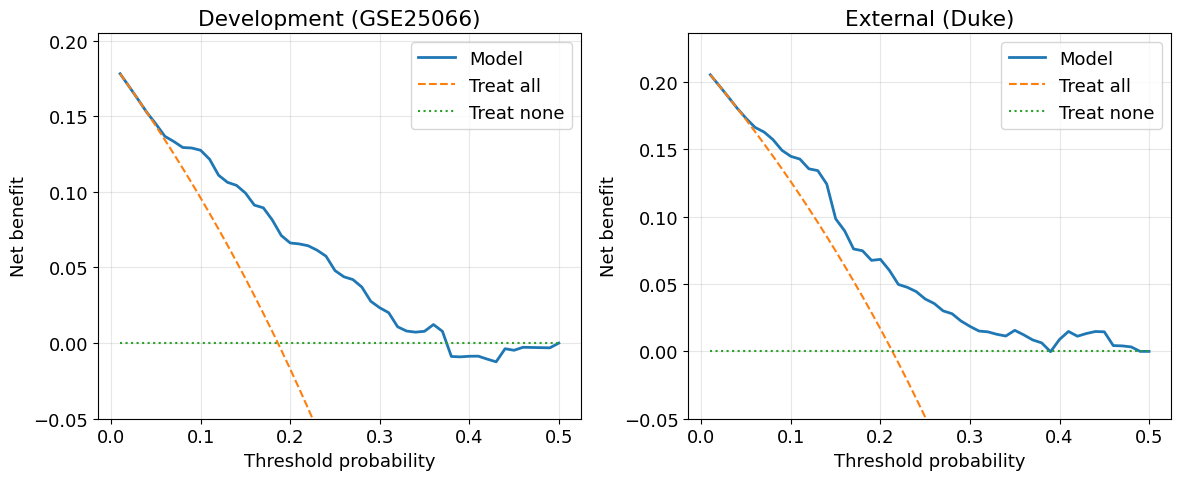

In [ ]:
tables = run({'Development (GSE25066)': (y_geo, oof_cal),
              'External (Duke)':        (yduke, p_duke)})
t = tables['External (Duke)']
print(t[t.threshold.isin([0.05,0.07,0.10,0.15,0.20,0.25])].to_string(index=False))

In [107]:
pipe = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

aucs = []
for seed in range(200):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    p = cross_val_predict(pipe, model_df[FINAL_FEATURES], y_geo,
                          cv=cv, method="predict_proba")[:, 1]
    aucs.append(roc_auc_score(y_geo, p))

aucs = np.array(aucs)
print(f"mean {aucs.mean():.3f}  SD {aucs.std():.3f}  "
      f"2.5–97.5% {np.percentile(aucs,2.5):.3f}–{np.percentile(aucs,97.5):.3f}")

mean 0.754  SD 0.007  2.5–97.5% 0.737–0.766


corr(oof_mean, oof_cal) = 0.978
mean AUC 0.754 (SD 0.007)


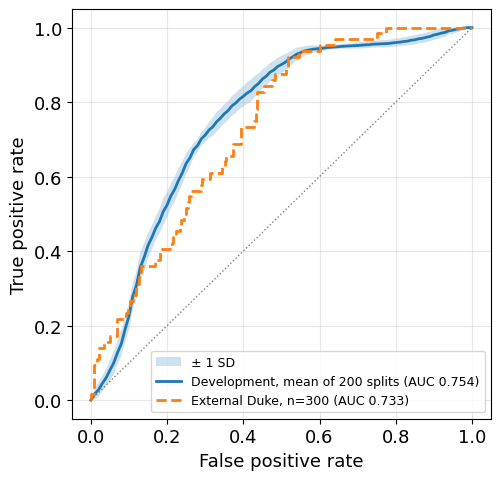

In [108]:


pipe = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
X, y = model_df[FINAL_FEATURES], y_geo

grid = np.linspace(0, 1, 101)     # common false-positive-rate axis
tprs, aucs, oof_store = [], [], []

for seed in range(200):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    p = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, p)
    tprs.append(np.interp(grid, fpr, tpr))   # put every curve on the same x-axis
    aucs.append(roc_auc_score(y, p))
    oof_store.append(p)

tprs = np.array(tprs); tprs[:, 0] = 0.0
mean_tpr, sd_tpr = tprs.mean(0), tprs.std(0)
mean_auc, sd_auc = np.mean(aucs), np.std(aucs)

# consistency check against the probabilities the DCA used
oof_mean = np.mean(oof_store, axis=0)
print('corr(oof_mean, oof_cal) =', np.corrcoef(oof_mean, oof_cal)[0, 1].round(3))
print(f'mean AUC {mean_auc:.3f} (SD {sd_auc:.3f})')

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.fill_between(grid, np.clip(mean_tpr-sd_tpr, 0, 1), np.clip(mean_tpr+sd_tpr, 0, 1),
                alpha=0.22, label='± 1 SD')
ax.plot(grid, mean_tpr, lw=2,
        label=f'Development, mean of 200 splits (AUC {mean_auc:.3f})')

p_duke_roc = calib.predict_proba(duke_model[FINAL_FEATURES])[:, 1]
f_d, t_d, _ = roc_curve(duke_model['pcr'], p_duke_roc)
ax.plot(f_d, t_d, lw=2, ls='--',
        label=f'External Duke, n=300 (AUC {roc_auc_score(duke_model["pcr"], p_duke_roc):.3f})')

ax.plot([0, 1], [0, 1], color='grey', lw=1, ls=':')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_curves.png', dpi=300)

In [109]:
import numpy as np, pandas as pd
from scipy.stats import chi2

def hosmer_lemeshow(y_true, y_prob, g=10):
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    df['grp'] = pd.qcut(df['p'], g, duplicates='drop')
    agg = df.groupby('grp', observed=True).agg(
        n=('y', 'size'), obs=('y', 'sum'), exp=('p', 'sum'))
    stat = (((agg['obs'] - agg['exp']) ** 2) /
            (agg['exp'] * (1 - agg['exp'] / agg['n']))).sum()
    dof = len(agg) - 2
    return stat, dof, 1 - chi2.cdf(stat, dof)

for name, y, p in [('Development', y_geo, oof_cal),
                   ('Duke', yduke, p_duke)]:
    s, d, pv = hosmer_lemeshow(y, p)
    print(f'{name:14} chi2={s:.2f}  df={d}  p={pv:.3f}')

Development    chi2=6.36  df=8  p=0.607
Duke           chi2=17.91  df=8  p=0.022


In [110]:
import time
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

Xdev, ydev = model_df[FINAL_FEATURES], y_geo
Xduke = duke_model[FINAL_FEATURES]
yduke = duke_model['pcr'].to_numpy(int)

N_SPLITS = 200
result_rows = []

for algo_name, algo in models.items():
    t0 = time.time()
    pipe = Pipeline([("prep", prep_final), ("model", algo)])

    internal = []
    for seed in range(N_SPLITS):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        oof = cross_val_predict(pipe, Xdev, ydev, cv=cv,
                                method="predict_proba", n_jobs=-1)[:, 1]
        internal.append(roc_auc_score(ydev, oof))
    internal = np.array(internal)
    int_lo, int_hi = np.percentile(internal, [2.5, 97.5])

    pipe.fit(Xdev, ydev)
    ext_prob = pipe.predict_proba(Xduke)[:, 1]
    ext_auc = roc_auc_score(yduke, ext_prob)

    rng = np.random.default_rng(42)
    boot = []
    for _ in range(2000):
        idx = rng.integers(0, len(yduke), len(yduke))
        if len(np.unique(yduke[idx])) == 2:
            boot.append(roc_auc_score(yduke[idx], ext_prob[idx]))
    ext_lo, ext_hi = np.percentile(boot, [2.5, 97.5])

    result_rows.append({
        'Model': algo_name,
        'Internal AUC': round(internal.mean(), 3),
        'Internal 2.5-97.5 pct': f'{int_lo:.3f}\u2013{int_hi:.3f}',
        'External AUC': round(ext_auc, 3),
        'External 95% CI': f'{ext_lo:.3f}\u2013{ext_hi:.3f}',
        'Delta': round(ext_auc - internal.mean(), 3)})
    print(f'{algo_name:24} int {internal.mean():.3f}  ext {ext_auc:.3f}  [{time.time()-t0:.0f}s]')

res = pd.DataFrame(result_rows).sort_values('Internal AUC', ascending=False)
print('\n' + res.to_string(index=False))
print(f"\nSpearman: {res['Internal AUC'].corr(res['External AUC'], method='spearman'):.2f}")
res.to_excel('algorithm_comparison_200.xlsx', index=False)

Logistic regression      int 0.754  ext 0.734  [34s]
Lasso (L1) logistic      int 0.754  ext 0.732  [25s]
Random forest            int 0.670  ext 0.630  [388s]
Gradient boosting        int 0.713  ext 0.659  [97s]
XGBoost                  int 0.723  ext 0.667  [48s]
SVM                      int 0.699  ext 0.698  [34s]
k-Nearest Neighbors      int 0.734  ext 0.725  [24s]
Naive Bayes              int 0.731  ext 0.753  [24s]

              Model  Internal AUC Internal 2.5-97.5 pct  External AUC External 95% CI  Delta
Logistic regression         0.754           0.737–0.766         0.734     0.672–0.797 -0.020
Lasso (L1) logistic         0.754           0.736–0.768         0.732     0.670–0.795 -0.022
k-Nearest Neighbors         0.734           0.707–0.758         0.725     0.661–0.787 -0.009
        Naive Bayes         0.731           0.703–0.755         0.753     0.690–0.813  0.022
            XGBoost         0.723           0.686–0.753         0.667     0.600–0.737 -0.056
  Gradient boost

AUC of the plotted curve   : 0.753
Mean AUC across 200 splits : 0.754 (2.5-97.5 pct 0.737–0.766)
Youden cutoff 0.40  Sens 0.84  Spec 0.61


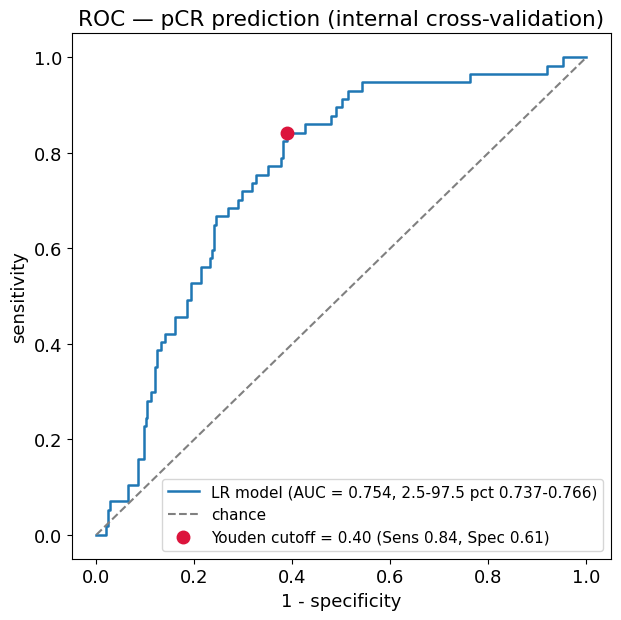

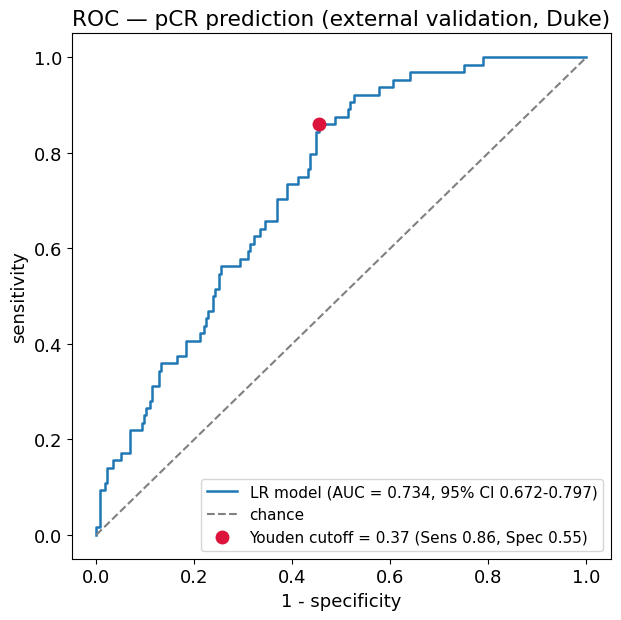

In [111]:


pipe = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
Xdev, ydev = model_df[FINAL_FEATURES], y_geo

# ---------- FIGURE 3 : internal ----------
probs, aucs = [], []
for seed in range(200):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    p = cross_val_predict(pipe, Xdev, ydev, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    probs.append(p)
    aucs.append(roc_auc_score(ydev, p))

p_mean = np.mean(probs, axis=0)
mean_auc = np.mean(aucs)
lo, hi = np.percentile(aucs, [2.5, 97.5])

fpr, tpr, thr = roc_curve(ydev, p_mean)
j = np.argmax(tpr - fpr)

print(f'AUC of the plotted curve   : {roc_auc_score(ydev, p_mean):.3f}')
print(f'Mean AUC across 200 splits : {mean_auc:.3f} (2.5-97.5 pct {lo:.3f}\u2013{hi:.3f})')
print(f'Youden cutoff {thr[j]:.2f}  Sens {tpr[j]:.2f}  Spec {1-fpr[j]:.2f}')

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(fpr, tpr, color='tab:blue', lw=1.8,
        label=f'LR model (AUC = {mean_auc:.3f}, 2.5-97.5 pct {lo:.3f}-{hi:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, ls='--', label='chance')
ax.plot(fpr[j], tpr[j], 'o', color='crimson', ms=9, zorder=5,
        label=f'Youden cutoff = {thr[j]:.2f} (Sens {tpr[j]:.2f}, Spec {1-fpr[j]:.2f})')
ax.set_xlabel('1 - specificity'); ax.set_ylabel('sensitivity')
ax.set_title('ROC \u2014 pCR prediction (internal cross-validation)')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout(); plt.savefig('fig3_roc_internal.png', dpi=300)
plt.show()

# ---------- FIGURE 5 : external ----------
p_ext = final_model.predict_proba(duke_model[FINAL_FEATURES])[:, 1]
y_ext = duke_model['pcr'].to_numpy(int)
fpr_e, tpr_e, thr_e = roc_curve(y_ext, p_ext)
auc_e = roc_auc_score(y_ext, p_ext)
k = np.argmax(tpr_e - fpr_e)

rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_ext), len(y_ext))
    if len(np.unique(y_ext[idx])) == 2:
        boot.append(roc_auc_score(y_ext[idx], p_ext[idx]))
elo, ehi = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.plot(fpr_e, tpr_e, color='tab:blue', lw=1.8,
        label=f'LR model (AUC = {auc_e:.3f}, 95% CI {elo:.3f}-{ehi:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, ls='--', label='chance')
ax.plot(fpr_e[k], tpr_e[k], 'o', color='crimson', ms=9, zorder=5,
        label=f'Youden cutoff = {thr_e[k]:.2f} (Sens {tpr_e[k]:.2f}, Spec {1-fpr_e[k]:.2f})')
ax.set_xlabel('1 - specificity'); ax.set_ylabel('sensitivity')
ax.set_title('ROC \u2014 pCR prediction (external validation, Duke)')
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout(); plt.savefig('fig5_roc_external.png', dpi=300)
plt.show()

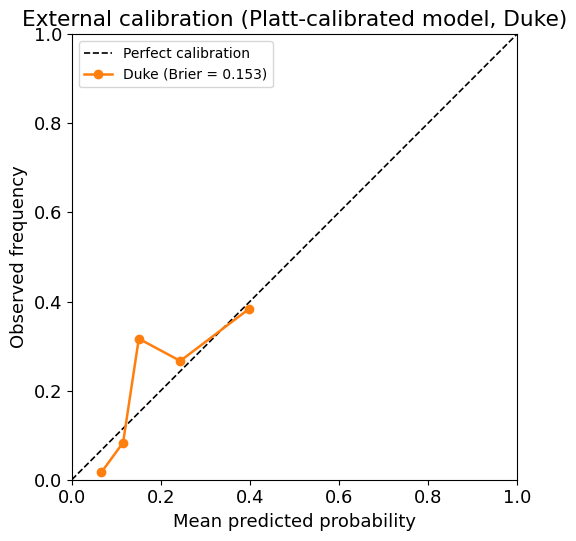

In [112]:


PRED = ['age_years', 'er_status_ihc', 'pr_status_ihc', 'grade']
y_ext = duke_model['pcr'].to_numpy(int)
p_ext = calib.predict_proba(duke_model[PRED])[:, 1]

brier = brier_score_loss(y_ext, p_ext)
prob_true, prob_pred = calibration_curve(y_ext, p_ext, n_bins=5, strategy='quantile')

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='tab:orange', lw=1.8, ms=6,
        label=f'Duke (Brier = {brier:.3f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed frequency')
ax.set_title('External calibration (Platt-calibrated model, Duke)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.savefig('fig6_calibration_external.png', dpi=300)
plt.show()

In [113]:
print('10 groups:', hosmer_lemeshow(y_ext, p_ext, g=10)[2].round(3))
print(' 5 groups:', hosmer_lemeshow(y_ext, p_ext, g=5)[2].round(3))

10 groups: 0.022
 5 groups: 0.001


In [114]:
print('internal 10:', hosmer_lemeshow(y_geo, oof_cal, g=10)[2].round(3))
print('internal  5:', hosmer_lemeshow(y_geo, oof_cal, g=5)[2].round(3))

internal 10: 0.607
internal  5: 0.239


In [115]:
plt.savefig('fig1_roc_external.png', dpi=300, bbox_inches='tight')
plt.savefig('fig2_calibration_external.png', dpi=300, bbox_inches='tight')
plt.savefig('fig3_dca.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [116]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# ---------- FIGURE 1: external ROC ----------
p_ext = calib.predict_proba(duke_model[FINAL_FEATURES])[:, 1]
y_ext = duke_model['pcr'].to_numpy(int)
fpr, tpr, thr = roc_curve(y_ext, p_ext)
auc = roc_auc_score(y_ext, p_ext)
k = np.argmax(tpr - fpr)

rng = np.random.default_rng(42)
boot = [roc_auc_score(y_ext[i], p_ext[i])
        for i in (rng.integers(0, len(y_ext), len(y_ext)) for _ in range(2000))
        if len(np.unique(y_ext[i])) == 2]
lo, hi = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color='tab:blue', lw=1.8,
        label=f'LR model (AUC = {auc:.3f}, 95% CI {lo:.3f}-{hi:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='chance')
ax.plot(fpr[k], tpr[k], 'o', color='crimson', ms=8,
        label=f'Youden cutoff = {thr[k]:.2f} (Sens {tpr[k]:.2f}, Spec {1-fpr[k]:.2f})')
ax.set_xlabel('1 - specificity'); ax.set_ylabel('sensitivity')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('fig1_roc_external.png', dpi=300, bbox_inches='tight')
plt.close()
print('fig1 saved')

fig1 saved


In [117]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ---------- FIGURE 2: external calibration ----------
brier = brier_score_loss(y_ext, p_ext)
prob_true, prob_pred = calibration_curve(y_ext, p_ext, n_bins=5, strategy='quantile')

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
ax.plot(prob_pred, prob_true, 'o-', color='tab:orange', lw=1.8, ms=6,
        label=f'Duke (Brier = {brier:.3f})')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed frequency')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_calibration_external.png', dpi=300, bbox_inches='tight')
plt.close()
print('fig2 saved')

fig2 saved


In [118]:
# ---------- FIGURE 3: decision curves ----------
tables = run({'Development (GSE25066)': (y_geo, oof_cal),
              'External (Duke)':        (y_ext, p_ext)})
plt.savefig('fig3_dca.png', dpi=300, bbox_inches='tight')
plt.close()
print('fig3 saved')

fig3 saved


In [119]:
import os
for f in ['fig1_roc_external.png', 'fig2_calibration_external.png', 'fig3_dca.png']:
    print(f, os.path.getsize(f), 'bytes')

fig1_roc_external.png 98925 bytes
fig2_calibration_external.png 97947 bytes
fig3_dca.png 225412 bytes


In [120]:
import os
print(os.getcwd())

c:\Users\HP\Desktop\python


In [121]:
import numpy as np, matplotlib.pyplot as plt, shap

# transform the development data through the fitted pipeline
X_trans = final_model.named_steps['prep'].transform(model_df[FINAL_FEATURES])
if hasattr(X_trans, 'toarray'):
    X_trans = X_trans.toarray()

raw_names = list(final_model.named_steps['prep'].get_feature_names_out())
print('raw names from pipeline:', raw_names)

PRETTY = {
    'age_years': 'Age',
    'num__age_years': 'Age',
    'er_status_ihc_P': 'ER positive',
    'cat__er_status_ihc_P': 'ER positive',
    'pr_status_ihc_P': 'PR positive',
    'cat__pr_status_ihc_P': 'PR positive',
    'grade_2': 'Grade 2',
    'cat__grade_2': 'Grade 2',
    'grade_3': 'Grade 3',
    'cat__grade_3': 'Grade 3',
}
names = [PRETTY.get(n, n.split('__')[-1].replace('_', ' ')) for n in raw_names]
print('display names        :', names)

explainer = shap.LinearExplainer(final_model.named_steps['model'], X_trans)
sv = explainer.shap_values(X_trans)

plt.figure(figsize=(6, 3.2))
shap.summary_plot(sv, X_trans, feature_names=names, show=False, plot_size=None)
plt.xlabel('SHAP value (impact on model output)', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_shap.png', dpi=300, bbox_inches='tight')
plt.close()
print('saved fig5_shap.png')

Background dataset has 306 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=306 when initializing the masker.


raw names from pipeline: ['num__age_years', 'cat__er_status_ihc_N', 'cat__er_status_ihc_P', 'cat__pr_status_ihc_N', 'cat__pr_status_ihc_P', 'cat__grade_1', 'cat__grade_2', 'cat__grade_3']
display names        : ['Age', 'er status ihc N', 'ER positive', 'pr status ihc N', 'PR positive', 'grade 1', 'Grade 2', 'Grade 3']
saved fig5_shap.png


In [122]:
m = final_model.named_steps['model']
print('coefficients:', m.coef_.shape[1])
print('names:', list(final_model.named_steps['prep'].get_feature_names_out()))

coefficients: 8
names: ['num__age_years', 'cat__er_status_ihc_N', 'cat__er_status_ihc_P', 'cat__pr_status_ihc_N', 'cat__pr_status_ihc_P', 'cat__grade_1', 'cat__grade_2', 'cat__grade_3']


In [123]:
PRETTY = {
    'num__age_years': 'Age',
    'cat__er_status_ihc_N': 'ER negative',
    'cat__er_status_ihc_P': 'ER positive',
    'cat__pr_status_ihc_N': 'PR negative',
    'cat__pr_status_ihc_P': 'PR positive',
    'cat__grade_1': 'Grade 1',
    'cat__grade_2': 'Grade 2',
    'cat__grade_3': 'Grade 3',
}


In [124]:
import matplotlib.pyplot as plt, shap

X_trans = final_model.named_steps['prep'].transform(model_df[FINAL_FEATURES])
if hasattr(X_trans, 'toarray'):
    X_trans = X_trans.toarray()

PRETTY = {
    'num__age_years': 'Age',
    'cat__er_status_ihc_N': 'ER negative',
    'cat__er_status_ihc_P': 'ER positive',
    'cat__pr_status_ihc_N': 'PR negative',
    'cat__pr_status_ihc_P': 'PR positive',
    'cat__grade_1': 'Grade 1',
    'cat__grade_2': 'Grade 2',
    'cat__grade_3': 'Grade 3',
}
raw = list(final_model.named_steps['prep'].get_feature_names_out())
names = [PRETTY.get(n, n) for n in raw]

explainer = shap.LinearExplainer(final_model.named_steps['model'], X_trans)
sv = explainer.shap_values(X_trans)

plt.figure(figsize=(6, 3.4))
shap.summary_plot(sv, X_trans, feature_names=names, show=False, plot_size=None)
plt.xlabel('SHAP value (impact on model output)', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_shap.png', dpi=300, bbox_inches='tight')
plt.close()
print('saved fig5_shap.png')

Background dataset has 306 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=306 when initializing the masker.


saved fig5_shap.png


In [125]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
import numpy as np

pipe = Pipeline([("prep", prep_final),
                 ("model", LogisticRegression(max_iter=1000,
                                              class_weight="balanced"))])

In [126]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
# Internal AUC + bootstrap CI (patient-level sampling uncertainty)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
p_int = cross_val_predict(pipe, model_df[FINAL_FEATURES], y_geo,
                          cv=cv, method="predict_proba")[:, 1]

int_auc = roc_auc_score(y_geo, p_int)
rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    i = rng.integers(0, len(y_geo), len(y_geo))
    if len(np.unique(y_geo.iloc[i])) == 2:
        boot.append(roc_auc_score(y_geo.iloc[i], p_int[i]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"Internal AUC: {int_auc:.3f}  (95% CI {lo:.3f}-{hi:.3f})")


Internal AUC: 0.757  (95% CI 0.690-0.815)


In [128]:
from scipy.stats import chi2_contingency

mask = duke_model["grade"].notna()
y    = duke_model["pcr"]

print("Grade recorded  n =", mask.sum(), " pCR rate =", round(y[mask].mean(), 3))
print("Grade missing   n =", (~mask).sum(), " pCR rate =", round(y[~mask].mean(), 3))

tab = pd.crosstab(mask, y)
print(tab)
print("chi2 p =", round(chi2_contingency(tab)[1], 3))

Grade recorded  n = 199  pCR rate = 0.231
Grade missing   n = 101  pCR rate = 0.178
pcr      0   1
grade         
False   83  18
True   153  46
chi2 p = 0.364


In [131]:
p_cc = final_model.predict_proba(duke_model.loc[mask, PRED])[:, 1]
y_cc   = duke_model.loc[mask, "pcr"].reset_index(drop=True)
cc_auc = roc_auc_score(y_cc, p_cc)

rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    i = rng.integers(0, len(y_cc), len(y_cc))
    if len(np.unique(y_cc.iloc[i])) == 2:
        boot.append(roc_auc_score(y_cc.iloc[i], p_cc[i]))
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Complete-case AUC (n={len(y_cc)}): {cc_auc:.3f} (95% CI {lo:.3f}-{hi:.3f})")

Complete-case AUC (n=199): 0.757 (95% CI 0.688-0.820)
